# Analyse du Paludisme au Sénégal — Projet AD

## Plan de la Présentation

| N° | Section | Contenu |
|----|---------|---------|
| **01** | **Contexte & Problématique** | Enjeux sanitaires du paludisme au Sénégal |
| **02** | **Données utilisées** | Source PNLP, 1 896 obs., 14 régions, 79 districts |
| **03** | **Pré-traitement** | Nettoyage, typage, variables temporelles |
| **04** | **Analyse descriptive** | KPIs, cas par région, évolution temporelle |
| **05** | **Corrélations** | Pearson, Spearman, Kendall – 25 variables |
| **06** | **Analyse factorielle ACP** | 3 axes, 85.7% de variance expliquée |
| **07** | **Clustering K-Means** | 3 profils : Faible / Moyen / Élevé |
| **08** | **Relations environnementales** | Carte, pluie, température, NDVI, hospitalisations |
| **09** | **Série temporelle & Prévisions** | Holt-Winters, Régression, Random Forest, SARIMA |
| **10** | **Application & Synthèse** | Dashboard, bilan, limites, recommandations |

---

## 01 — Contexte & Problématique

Le **paludisme** demeure un problème de santé publique majeur au Sénégal :

- **Vecteur** : *Anopheles gambiae* — moustique présent dans les zones humides
- **Saisonnalité** : pic en saison des pluies (juillet – octobre), favorisé par précipitations et températures élevées
- **Impact** : forte mortalité infantile, pression sur les systèmes de santé, pertes économiques

**Problématique** : Quels facteurs climatiques et environnementaux expliquent la variabilité spatiale et temporelle de l'incidence du paludisme au Sénégal ?

**Objectif** : Identifier les zones et périodes à risque, modéliser l'incidence et proposer un outil d'aide à la décision pour le Programme National de Lutte contre le Paludisme (PNLP).


## 02 — Données utilisées

Import des bibliothèques et lecture du fichier `malaria.xlsx`.

- **Source** : Programme National de Lutte contre le Paludisme (PNLP)
- **Volume** : 1 896 observations, 14 régions, 79 districts sanitaires
- **Période** : données mensuelles pluriannuelles
- **Variables** : épidémiologiques, climatiques (température, précipitations, humidité, NDVI)

In [1]:
import os
import re
import unicodedata
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# Chargement des données
file_path = os.path.join("..", "donnees", "malaria.xlsx")
df_raw = pd.read_excel(file_path)
print("Dimensions initiales:", df_raw.shape)
df_raw.head()

Dimensions initiales: (1896, 28)


,district,dept,region,ndvi,total_cas,cas_suspects,tdr_total,cas_paludisme_confirmes,humidite,precipitation,...,goutte_epaisse_positif_hosp,tdr_hosp,tdr_positif_hosp,total_tests_hosp,palu_fem_hosp,palu_masc_hosp,deces_total,deces_palu_fem,deces_palu_masc,deces_palu_total
0,BAKEL,BAKEL,TAMBACOUNDA,0.231050,8201,1563,1563,41,49.54,0.00,...,0.0,22.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0
1,BAKEL,BAKEL,TAMBACOUNDA,0.276295,8992,2238,2238,182,66.28,0.05,...,0.0,26.0,8.0,8.0,6.0,2.0,2.0,0.0,0.0,0.0
2,BAKEL,BAKEL,TAMBACOUNDA,0.347510,12543,4610,4610,800,78.09,1.53,...,0.0,42.0,12.0,12.0,6.0,6.0,4.0,1.0,1.0,2.0
3,BAKEL,BAKEL,TAMBACOUNDA,0.508219,11940,4658,4658,1106,84.28,9.19,...,0.0,48.0,20.0,20.0,13.0,7.0,3.0,0.0,0.0,0.0
4,BAKEL,BAKEL,TAMBACOUNDA,0.462662,8466,2023,2023,422,84.96,13.82,...,0.0,40.0,9.0,9.0,4.0,5.0,6.0,0.0,0.0,0.0


## 03 — Pré-traitement des données

Nettoyage, renommage des variables, conversion de types et création de la variable date.

- Suppression des doublons et harmonisation des noms de colonnes
- Conversion des variables numériques (coition des erreurs)
- Construction d'une date mensuelle à partir des colonnes `mois` et `annee`
- Imputation des valeurs manquantes sur les variables météo (médiane)

In [2]:
# =============================
# A) PRE-TRAITEMENT DES DONNEES
# =============================
# Les variables sont deja renommees dans le fichier source.

df = df_raw.copy()

# Nettoyage leger des noms de colonnes (espaces parasites)
df.columns = [str(c).strip() for c in df.columns]

# Harmonisation minimale de quelques aliases/casses observes
col_lookup = {c.lower(): c for c in df.columns}
minimal_alias = {
    "pop": "population",
    "incidence_1000": "incident_1000",
    "incidence_par_1000": "incident_1000",
}
for old_key, new_col in minimal_alias.items():
    if old_key in col_lookup:
        old_col = col_lookup[old_key]
        if old_col != new_col and new_col not in df.columns:
            df = df.rename(columns={old_col: new_col})

# Conversion des colonnes numeriques (si presentes)
num_candidates = [
    "population", "incident_1000", "ndvi", "humidite", "precipitation", "temperature",
    "total_cas", "cas_suspects", "tdr_total", "cas_paludisme_confirmes", "hospitalisations_total",
    "cas_suspects_hosp", "goutte_epaisse_positif_hosp", "goutte_epaisse_hosp", "tdr_hosp",
    "tdr_positif_hosp", "total_tests_hosp", "palu_fem_hosp", "palu_masc_hosp", "deces_total",
    "deces_palu_fem", "deces_palu_masc", "deces_palu_total"
]
for col in num_candidates:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Creation d'une date mensuelle robuste (mois texte ou numerique)
if "mois" in df.columns and "annee" in df.columns:
    month_map = {
        "jan": 1, "janvier": 1,
        "fev": 2, "fevrier": 2, "fvr": 2,
        "mar": 3, "mars": 3,
        "avr": 4, "avril": 4,
        "mai": 5,
        "jun": 6, "juin": 6,
        "jul": 7, "juil": 7, "juillet": 7,
        "aou": 8, "aout": 8,
        "sep": 9, "sept": 9, "septembre": 9,
        "oct": 10, "octobre": 10,
        "nov": 11, "novembre": 11,
        "dec": 12, "decembre": 12,
    }

    def parse_month(v):
        if pd.isna(v):
            return np.nan
        if isinstance(v, (int, float)):
            m = int(v)
            return m if 1 <= m <= 12 else np.nan
        s = str(v).strip().lower()
        if s.isdigit():
            m = int(s)
            return m if 1 <= m <= 12 else np.nan
        return month_map.get(s, np.nan)

    df["annee"] = pd.to_numeric(df["annee"], errors="coerce")
    df["mois_num"] = df["mois"].apply(parse_month)
    df["date"] = pd.to_datetime(
        dict(year=df["annee"], month=df["mois_num"], day=1),
        errors="coerce"
    )

# Doublons
nb_doublons = df.duplicated().sum()
if nb_doublons > 0:
    df = df.drop_duplicates().copy()

# Valeurs manquantes simples sur variables meteo/environnement
for col in ["ndvi", "humidite", "precipitation", "temperature"]:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

print("Dimensions apres pretraitement:", df.shape)
print("Doublons supprimes:", int(nb_doublons))
if "date" in df.columns:
    print("Dates valides:", int(df["date"].notna().sum()), "/", len(df))
print("Colonnes disponibles:")
print(sorted(df.columns))

df.head()

Dimensions apres pretraitement: (1896, 30)
Doublons supprimes: 0
Dates valides: 1422 / 1896
Colonnes disponibles:
['annee', 'cas_paludisme_confirmes', 'cas_suspects', 'cas_suspects_hosp', 'date', 'deces_palu_fem', 'deces_palu_masc', 'deces_palu_total', 'deces_total', 'dept', 'district', 'goutte_epaisse_hosp', 'goutte_epaisse_positif_hosp', 'hospitalisations_total', 'humidite', 'incident_1000', 'mois', 'mois_num', 'ndvi', 'palu_fem_hosp', 'palu_masc_hosp', 'population', 'precipitation', 'region', 'tdr_hosp', 'tdr_positif_hosp', 'tdr_total', 'temperature', 'total_cas', 'total_tests_hosp']


,district,dept,region,ndvi,total_cas,cas_suspects,tdr_total,cas_paludisme_confirmes,humidite,precipitation,...,tdr_positif_hosp,total_tests_hosp,palu_fem_hosp,palu_masc_hosp,deces_total,deces_palu_fem,deces_palu_masc,deces_palu_total,mois_num,date
0,BAKEL,BAKEL,TAMBACOUNDA,0.231050,8201,1563,1563,41,49.54,0.00,...,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,NaN,NaT
1,BAKEL,BAKEL,TAMBACOUNDA,0.276295,8992,2238,2238,182,66.28,0.05,...,8.0,8.0,6.0,2.0,2.0,0.0,0.0,0.0,11.0,2021-11-01
2,BAKEL,BAKEL,TAMBACOUNDA,0.347510,12543,4610,4610,800,78.09,1.53,...,12.0,12.0,6.0,6.0,4.0,1.0,1.0,2.0,10.0,2021-10-01
3,BAKEL,BAKEL,TAMBACOUNDA,0.508219,11940,4658,4658,1106,84.28,9.19,...,20.0,20.0,13.0,7.0,3.0,0.0,0.0,0.0,9.0,2021-09-01
4,BAKEL,BAKEL,TAMBACOUNDA,0.462662,8466,2023,2023,422,84.96,13.82,...,9.0,9.0,4.0,5.0,6.0,0.0,0.0,0.0,NaN,NaT


## 04 — Analyse descriptive

Statistiques descriptives et premières visualisations.

- KPIs globaux : cas confirmés, décès, incidence/1000
- Distribution des cas par région
- Évolution temporelle mensuelle des cas confirmés

                              count unique       top freq  \
district                       1896     79     BAKEL   24   
dept                           1896     46     LOUGA   96   
region                         1896     14     DAKAR  288   
ndvi                         1896.0    NaN       NaN  NaN   
total_cas                    1896.0    NaN       NaN  NaN   
cas_suspects                 1896.0    NaN       NaN  NaN   
tdr_total                    1896.0    NaN       NaN  NaN   
cas_paludisme_confirmes      1896.0    NaN       NaN  NaN   
humidite                     1896.0    NaN       NaN  NaN   
precipitation                1896.0    NaN       NaN  NaN   
temperature                  1896.0    NaN       NaN  NaN   
population                   1896.0    NaN       NaN  NaN   
incident_1000                1896.0    NaN       NaN  NaN   
mois                           1896     12  DÉCEMBRE  158   
annee                        1896.0    NaN       NaN  NaN   
hospitalisations_total  

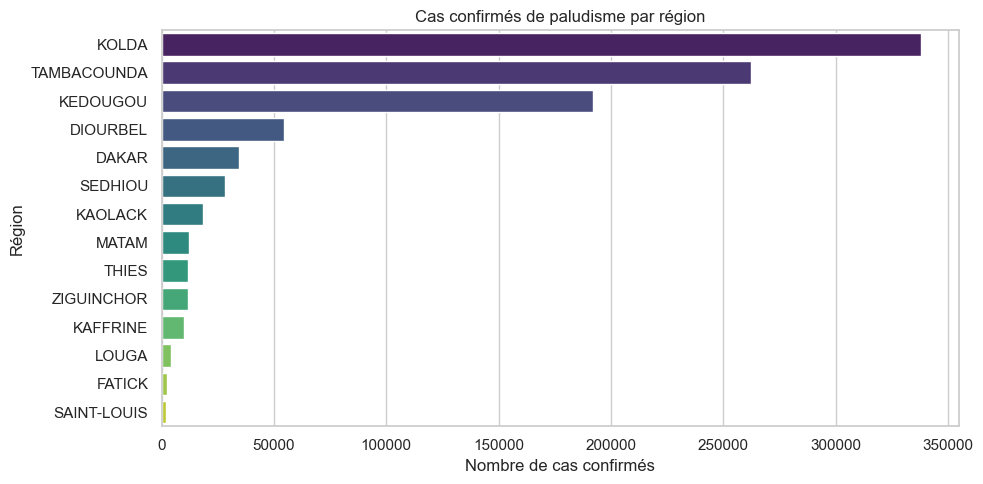

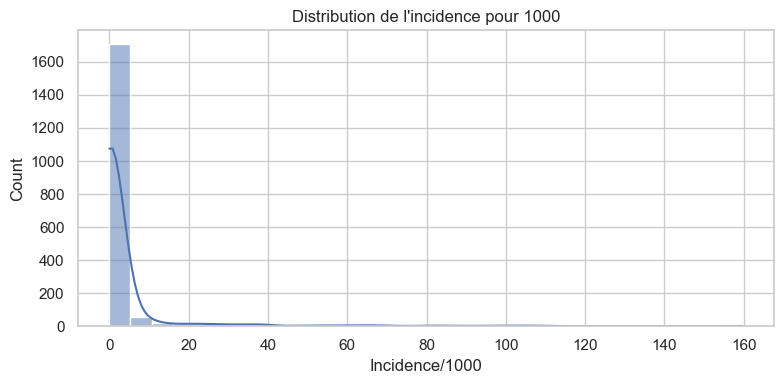

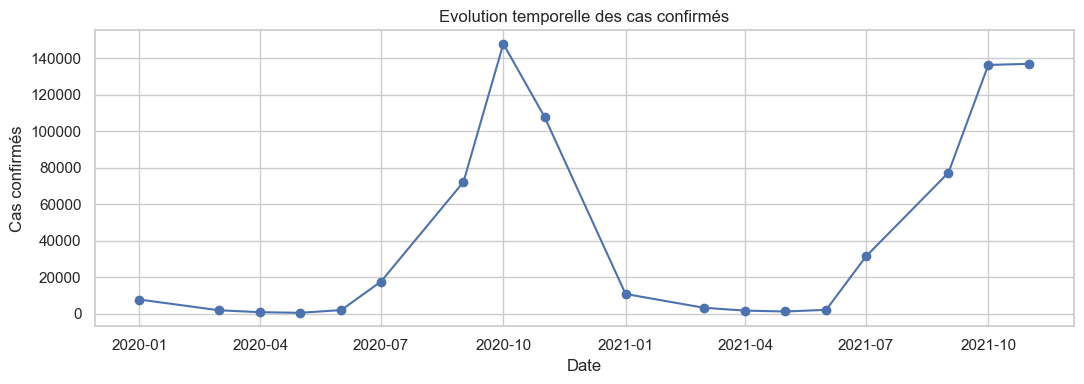

In [3]:

# B) ANALYSE DESCRIPTIVE


# Aperçu général
print(df.describe(include="all").T)

# Statistiques ciblées
target_cols = [c for c in ["incident_1000", "total_cas", "cas_paludisme_confirmes", "deces_palu_total"] if c in df.columns]
if target_cols:
    print("\nStatistiques cibles:\n")
    print(df[target_cols].describe().T)

# Cas confirmés par région
if "region" in df.columns and "cas_paludisme_confirmes" in df.columns:
    region_cases = (
        df.groupby("region", dropna=False)["cas_paludisme_confirmes"]
        .sum()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(10, 5))
    sns.barplot(x=region_cases.values, y=region_cases.index, palette="viridis")
    plt.title("Cas confirmés de paludisme par région")
    plt.xlabel("Nombre de cas confirmés")
    plt.ylabel("Région")
    plt.tight_layout()
    plt.show()

# Distribution de l'incidence
if "incident_1000" in df.columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(df["incident_1000"], kde=True, bins=30)
    plt.title("Distribution de l'incidence pour 1000")
    plt.xlabel("Incidence/1000")
    plt.tight_layout()
    plt.show()

# Série simple: évolution des cas confirmés dans le temps
if "date" in df.columns and "cas_paludisme_confirmes" in df.columns:
    ts_tmp = (
        df.dropna(subset=["date"])
        .groupby("date")["cas_paludisme_confirmes"]
        .sum()
        .sort_index()
    )

    if len(ts_tmp) > 0:
        plt.figure(figsize=(11, 4))
        plt.plot(ts_tmp.index, ts_tmp.values, marker="o")
        plt.title("Evolution temporelle des cas confirmés")
        plt.xlabel("Date")
        plt.ylabel("Cas confirmés")
        plt.tight_layout()
        plt.show()
    else:
        print("Aucune date exploitable pour l'évolution temporelle.")

## 05 — Corrélations

Analyse des relations entre toutes les variables numériques.

- Matrices de corrélation (Pearson, Spearman, Kendall)
- Scatter plots incidence vs variables explicatives (NDVI, pluie, température, population)

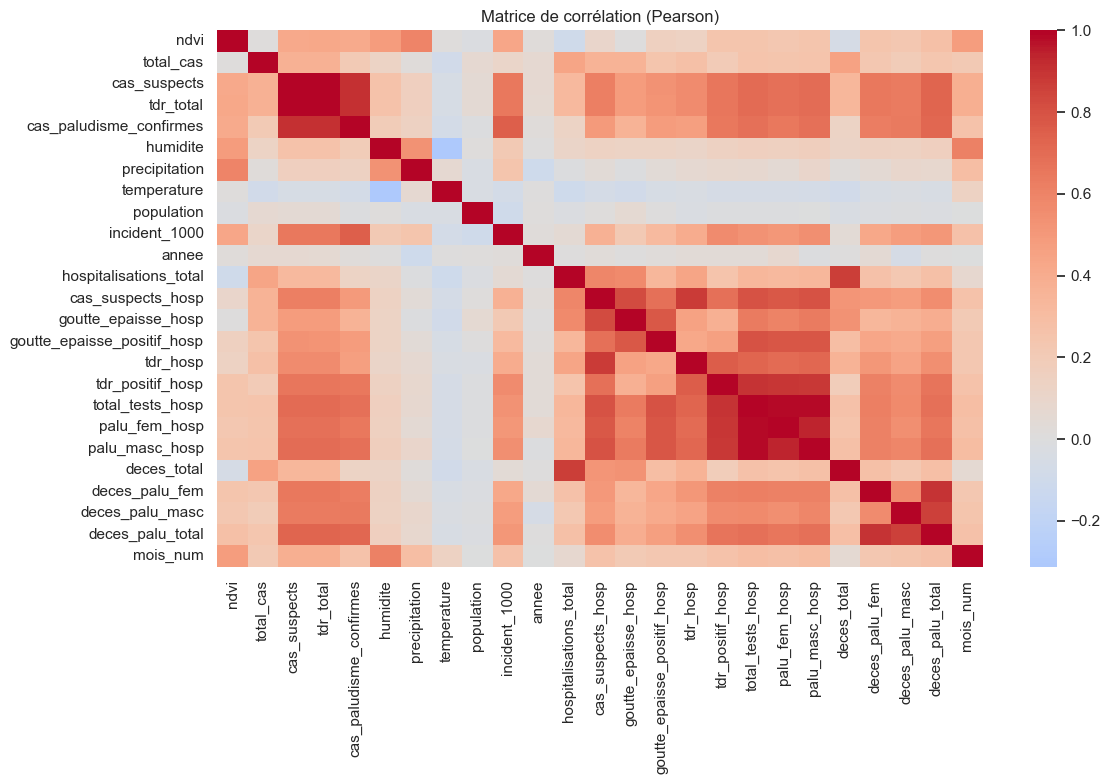

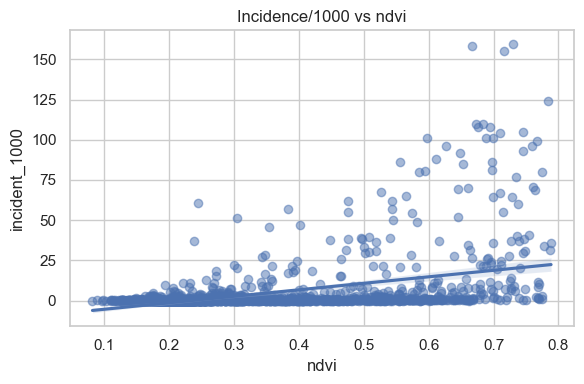

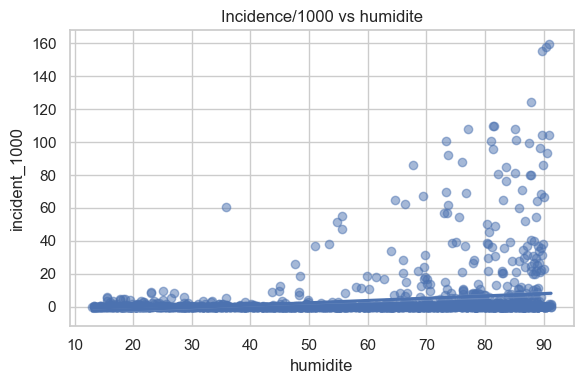

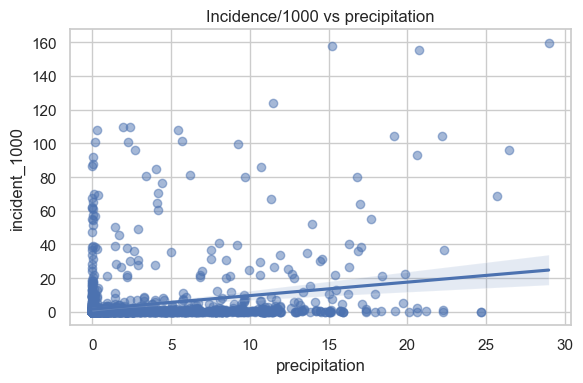

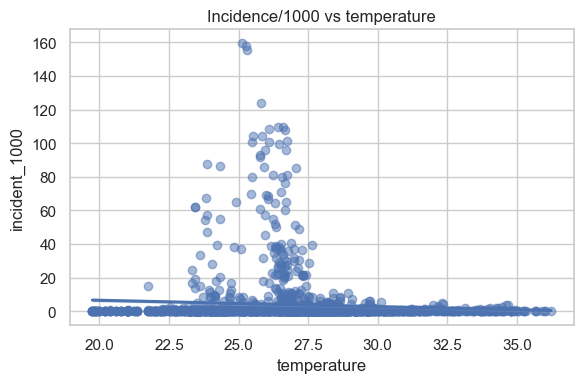

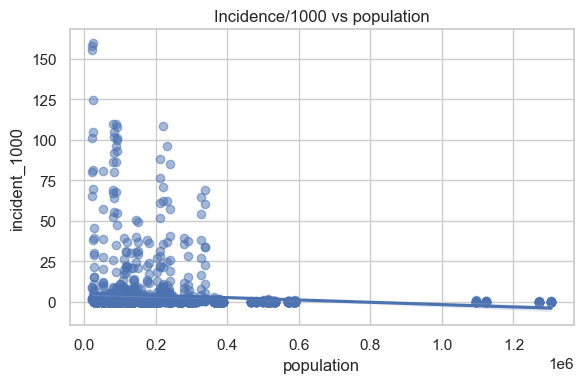

Corrélations incidence_1000:
incident_1000                  1.000000
cas_paludisme_confirmes        0.753736
tdr_total                      0.649291
cas_suspects                   0.648020
tdr_positif_hosp               0.566547
palu_masc_hosp                 0.547627
total_tests_hosp               0.537148
palu_fem_hosp                  0.510779
deces_palu_total               0.509760
deces_palu_masc                0.477897
ndvi                           0.432066
deces_palu_fem                 0.427172
tdr_hosp                       0.403882
cas_suspects_hosp              0.371247
goutte_epaisse_positif_hosp    0.316625
mois_num                       0.271532
precipitation                  0.241814
goutte_epaisse_hosp            0.213429
humidite                       0.211268
total_cas                      0.104643
hospitalisations_total         0.048005
deces_total                    0.042158
annee                          0.015978
temperature                   -0.075064
population 

In [4]:

# C) ANALYSE DES CORRELATIONS


num_df = df.select_dtypes(include=[np.number]).copy()

if num_df.shape[1] >= 2:
    corr_pearson = num_df.corr(method="pearson")

    plt.figure(figsize=(12, 8))
    sns.heatmap(corr_pearson, cmap="coolwarm", center=0)
    plt.title("Matrice de corrélation (Pearson)")
    plt.tight_layout()
    plt.show()

    if "incident_1000" in num_df.columns:
        vars_to_compare = [c for c in ["ndvi", "humidite", "precipitation", "temperature", "population"] if c in num_df.columns]
        for v in vars_to_compare:
            plt.figure(figsize=(6, 4))
            sns.regplot(data=df, x=v, y="incident_1000", scatter_kws={"alpha": 0.5})
            plt.title(f"Incidence/1000 vs {v}")
            plt.tight_layout()
            plt.show()

        print("Corrélations incidence_1000:")
        print(corr_pearson["incident_1000"].sort_values(ascending=False))
else:
    print("Pas assez de variables numériques pour la corrélation.")

### Relations exhaustives — Pearson, Spearman, Kendall

Tableau pair-à-pair pour toutes les combinaisons de variables numériques, classées par force de corrélation (|Pearson|).

Variables utilisees (relations exhaustives):
['ndvi', 'total_cas', 'cas_suspects', 'tdr_total', 'cas_paludisme_confirmes', 'humidite', 'precipitation', 'temperature', 'population', 'incident_1000', 'annee', 'hospitalisations_total', 'cas_suspects_hosp', 'goutte_epaisse_hosp', 'goutte_epaisse_positif_hosp', 'tdr_hosp', 'tdr_positif_hosp', 'total_tests_hosp', 'palu_fem_hosp', 'palu_masc_hosp', 'deces_total', 'deces_palu_fem', 'deces_palu_masc', 'deces_palu_total', 'mois_num']

Matrice Pearson:


,ndvi,total_cas,cas_suspects,tdr_total,cas_paludisme_confirmes,humidite,precipitation,temperature,population,incident_1000,...,tdr_hosp,tdr_positif_hosp,total_tests_hosp,palu_fem_hosp,palu_masc_hosp,deces_total,deces_palu_fem,deces_palu_masc,deces_palu_total,mois_num
ndvi,1.000,0.015,0.420,0.422,0.406,0.487,0.598,0.011,-0.018,0.432,...,0.137,0.246,0.242,0.227,0.250,-0.052,0.250,0.233,0.274,0.480
total_cas,0.015,1.000,0.374,0.372,0.207,0.124,0.016,-0.087,0.070,0.105,...,0.275,0.197,0.255,0.248,0.255,0.453,0.231,0.192,0.241,0.211
cas_suspects,0.420,0.374,1.000,1.000,0.907,0.261,0.163,-0.050,0.050,0.648,...,0.568,0.659,0.703,0.682,0.702,0.342,0.646,0.640,0.728,0.387
tdr_total,0.422,0.372,1.000,1.000,0.909,0.260,0.163,-0.049,0.051,0.649,...,0.568,0.660,0.703,0.682,0.702,0.338,0.646,0.640,0.728,0.387
cas_paludisme_confirmes,0.406,0.207,0.907,0.909,1.000,0.191,0.144,-0.071,-0.010,0.754,...,0.476,0.656,0.680,0.654,0.686,0.124,0.630,0.642,0.719,0.263
humidite,0.487,0.124,0.261,0.260,0.191,1.000,0.536,-0.312,0.011,0.211,...,0.116,0.149,0.163,0.152,0.169,0.120,0.145,0.138,0.160,0.615
precipitation,0.598,0.016,0.163,0.163,0.144,0.536,1.000,0.068,-0.034,0.242,...,0.064,0.084,0.076,0.056,0.095,0.019,0.051,0.091,0.079,0.291
temperature,0.011,-0.087,-0.050,-0.049,-0.071,-0.312,0.068,1.000,-0.035,-0.075,...,-0.034,-0.052,-0.059,-0.054,-0.062,-0.084,-0.040,-0.023,-0.036,0.143
population,-0.018,0.070,0.050,0.051,-0.010,0.011,-0.034,-0.035,1.000,-0.100,...,-0.026,-0.012,-0.006,-0.008,-0.004,-0.035,-0.016,-0.010,-0.015,-0.000
incident_1000,0.432,0.105,0.648,0.649,0.754,0.211,0.242,-0.075,-0.100,1.000,...,0.404,0.567,0.537,0.511,0.548,0.042,0.427,0.478,0.510,0.272


Matrice Spearman:


,ndvi,total_cas,cas_suspects,tdr_total,cas_paludisme_confirmes,humidite,precipitation,temperature,population,incident_1000,...,tdr_hosp,tdr_positif_hosp,total_tests_hosp,palu_fem_hosp,palu_masc_hosp,deces_total,deces_palu_fem,deces_palu_masc,deces_palu_total,mois_num
ndvi,1.000,-0.031,0.402,0.405,0.581,0.401,0.418,0.040,0.074,0.552,...,0.061,0.305,0.356,0.331,0.339,-0.037,0.247,0.205,0.261,0.471
total_cas,-0.031,1.000,0.733,0.731,0.453,0.295,0.139,-0.152,0.307,0.374,...,0.511,0.415,0.520,0.491,0.473,0.704,0.330,0.301,0.383,0.218
cas_suspects,0.402,0.733,1.000,1.000,0.818,0.347,0.230,-0.028,0.235,0.746,...,0.520,0.625,0.719,0.691,0.669,0.461,0.422,0.393,0.495,0.508
tdr_total,0.405,0.731,1.000,1.000,0.818,0.344,0.230,-0.025,0.237,0.746,...,0.519,0.625,0.718,0.691,0.668,0.458,0.422,0.392,0.494,0.508
cas_paludisme_confirmes,0.581,0.453,0.818,0.818,1.000,0.381,0.217,-0.094,0.095,0.960,...,0.394,0.687,0.782,0.739,0.739,0.254,0.430,0.384,0.491,0.543
humidite,0.401,0.295,0.347,0.344,0.381,1.000,0.703,-0.219,-0.034,0.375,...,0.081,0.280,0.362,0.330,0.353,0.163,0.193,0.175,0.218,0.571
precipitation,0.418,0.139,0.230,0.230,0.217,0.703,1.000,0.197,-0.012,0.211,...,0.054,0.148,0.190,0.161,0.190,0.078,0.106,0.086,0.121,0.466
temperature,0.040,-0.152,-0.028,-0.025,-0.094,-0.219,0.197,1.000,0.028,-0.088,...,-0.029,-0.098,-0.137,-0.124,-0.132,-0.088,-0.051,-0.044,-0.050,0.141
population,0.074,0.307,0.235,0.237,0.095,-0.034,-0.012,0.028,1.000,-0.144,...,-0.007,0.023,0.039,0.031,0.032,0.127,0.014,0.007,0.016,0.000
incident_1000,0.552,0.374,0.746,0.746,0.960,0.375,0.211,-0.088,-0.144,1.000,...,0.396,0.667,0.757,0.718,0.715,0.228,0.426,0.384,0.485,0.535


Matrice Kendall:


,ndvi,total_cas,cas_suspects,tdr_total,cas_paludisme_confirmes,humidite,precipitation,temperature,population,incident_1000,...,tdr_hosp,tdr_positif_hosp,total_tests_hosp,palu_fem_hosp,palu_masc_hosp,deces_total,deces_palu_fem,deces_palu_masc,deces_palu_total,mois_num
ndvi,1.000,-0.019,0.277,0.279,0.414,0.304,0.292,0.013,0.049,0.389,...,0.041,0.231,0.263,0.249,0.256,-0.024,0.200,0.166,0.209,0.304
total_cas,-0.019,1.000,0.539,0.537,0.315,0.195,0.094,-0.101,0.205,0.258,...,0.362,0.315,0.389,0.373,0.360,0.526,0.267,0.244,0.307,0.153
cas_suspects,0.277,0.539,1.000,0.995,0.635,0.232,0.158,-0.023,0.157,0.559,...,0.371,0.494,0.563,0.547,0.527,0.326,0.343,0.321,0.403,0.355
tdr_total,0.279,0.537,0.995,1.000,0.635,0.230,0.158,-0.021,0.157,0.558,...,0.371,0.494,0.563,0.547,0.527,0.325,0.343,0.321,0.402,0.356
cas_paludisme_confirmes,0.414,0.315,0.635,0.635,1.000,0.261,0.153,-0.070,0.066,0.841,...,0.279,0.563,0.636,0.601,0.600,0.180,0.355,0.318,0.404,0.388
humidite,0.304,0.195,0.232,0.230,0.261,1.000,0.531,-0.172,-0.021,0.255,...,0.056,0.210,0.263,0.246,0.263,0.113,0.155,0.141,0.174,0.394
precipitation,0.292,0.094,0.158,0.158,0.153,0.531,1.000,0.118,-0.008,0.147,...,0.037,0.113,0.140,0.122,0.145,0.055,0.087,0.072,0.099,0.335
temperature,0.013,-0.101,-0.023,-0.021,-0.070,-0.172,0.118,1.000,0.018,-0.064,...,-0.020,-0.075,-0.102,-0.095,-0.101,-0.061,-0.042,-0.036,-0.042,0.046
population,0.049,0.205,0.157,0.157,0.066,-0.021,-0.008,0.018,1.000,-0.099,...,-0.005,0.017,0.029,0.023,0.024,0.088,0.011,0.006,0.013,0.000
incident_1000,0.389,0.258,0.559,0.558,0.841,0.255,0.147,-0.064,-0.099,1.000,...,0.278,0.539,0.608,0.576,0.574,0.162,0.349,0.315,0.397,0.380


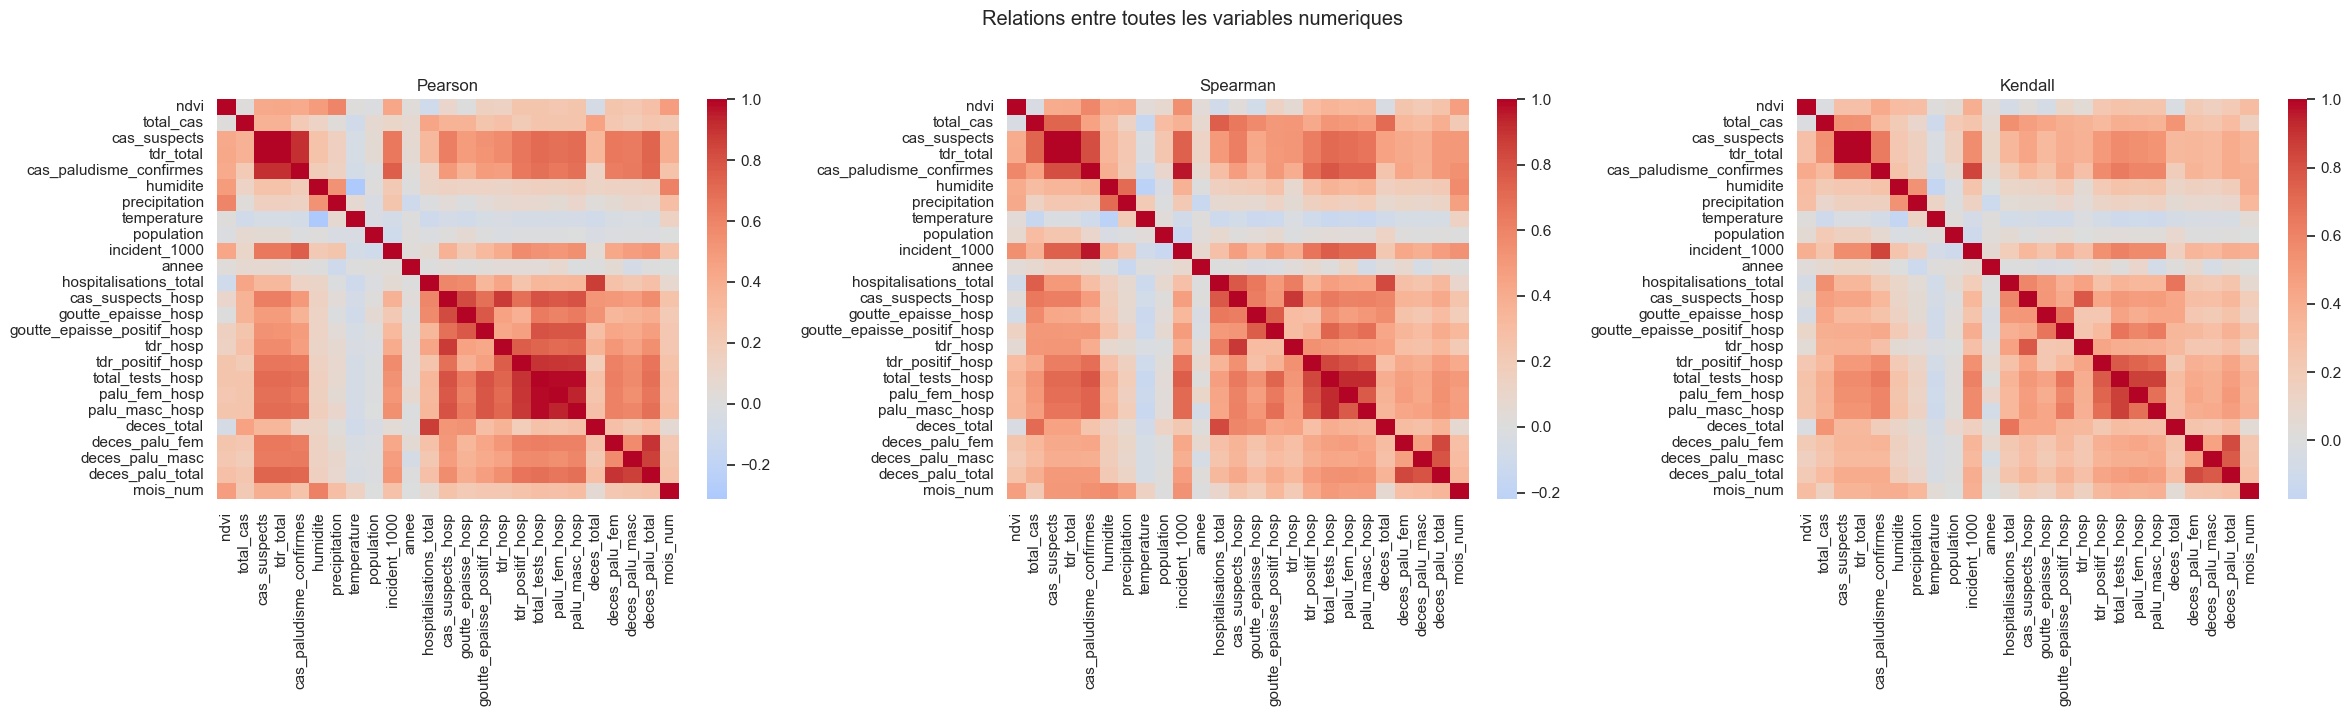


Tableau exhaustif des relations (toutes les paires):


,var_1,var_2,n_obs,pearson,spearman,kendall,abs_pearson
0,cas_suspects,tdr_total,1896,0.9999,0.9997,0.9949,0.9999
1,total_tests_hosp,palu_fem_hosp,1848,0.9851,0.9243,0.8658,0.9851
2,total_tests_hosp,palu_masc_hosp,1848,0.9820,0.9207,0.8613,0.9820
3,palu_fem_hosp,palu_masc_hosp,1848,0.9348,0.7666,0.6837,0.9348
4,tdr_total,cas_paludisme_confirmes,1896,0.9085,0.8176,0.6353,0.9085
...,...,...,...,...,...,...,...
295,population,palu_masc_hosp,1848,-0.0036,0.0323,0.0241,0.0036
296,temperature,annee,1896,0.0019,0.0150,0.0123,0.0019
297,annee,hospitalisations_total,1848,0.0015,0.0069,0.0057,0.0015
298,population,mois_num,1422,-0.0000,0.0000,0.0000,0.0000


Top 20 relations les plus fortes (|Pearson|):


,var_1,var_2,n_obs,pearson,spearman,kendall,abs_pearson
0,cas_suspects,tdr_total,1896,0.9999,0.9997,0.9949,0.9999
1,total_tests_hosp,palu_fem_hosp,1848,0.9851,0.9243,0.8658,0.9851
2,total_tests_hosp,palu_masc_hosp,1848,0.9820,0.9207,0.8613,0.9820
3,palu_fem_hosp,palu_masc_hosp,1848,0.9348,0.7666,0.6837,0.9348
4,tdr_total,cas_paludisme_confirmes,1896,0.9085,0.8176,0.6353,0.9085
5,cas_suspects,cas_paludisme_confirmes,1896,0.9069,0.8176,0.6352,0.9069
6,tdr_positif_hosp,total_tests_hosp,1848,0.9019,0.8340,0.7671,0.9019
7,deces_palu_fem,deces_palu_total,1848,0.9006,0.8388,0.8245,0.9006
8,tdr_positif_hosp,palu_fem_hosp,1848,0.8885,0.8025,0.7331,0.8885
9,tdr_positif_hosp,palu_masc_hosp,1848,0.8856,0.7615,0.6904,0.8856


In [5]:
from itertools import combinations

# Variables numeriques candidates
num_cols_all = df.select_dtypes(include=[np.number]).columns.tolist()

# Garder uniquement les variables exploitables pour la correlation
valid_cols = []
for c in num_cols_all:
    s = pd.to_numeric(df[c], errors="coerce")
    if s.notna().sum() >= 10 and s.nunique(dropna=True) > 1:
        valid_cols.append(c)

if len(valid_cols) < 2:
    print("Pas assez de variables numeriques exploitables pour les relations exhaustives.")
else:
    rel_num = df[valid_cols].apply(pd.to_numeric, errors="coerce")

    print("Variables utilisees (relations exhaustives):")
    print(valid_cols)

    # Matrices de correlation completes
    corr_pearson_all = rel_num.corr(method="pearson")
    corr_spearman_all = rel_num.corr(method="spearman")
    corr_kendall_all = rel_num.corr(method="kendall")

    print("\nMatrice Pearson:")
    display(corr_pearson_all.round(3))

    print("Matrice Spearman:")
    display(corr_spearman_all.round(3))

    print("Matrice Kendall:")
    display(corr_kendall_all.round(3))

    # Heatmaps complets
    fig, axes = plt.subplots(1, 3, figsize=(24, 7))
    sns.heatmap(corr_pearson_all, cmap="coolwarm", center=0, ax=axes[0])
    axes[0].set_title("Pearson")

    sns.heatmap(corr_spearman_all, cmap="coolwarm", center=0, ax=axes[1])
    axes[1].set_title("Spearman")

    sns.heatmap(corr_kendall_all, cmap="coolwarm", center=0, ax=axes[2])
    axes[2].set_title("Kendall")

    plt.suptitle("Relations entre toutes les variables numeriques", y=1.02)
    plt.tight_layout()
    plt.show()

    # Tableau pair-a-pair exhaustif
    rows = []
    for a, b in combinations(valid_cols, 2):
        pair_df = rel_num[[a, b]].dropna()
        n_obs = len(pair_df)
        if n_obs < 10:
            continue

        p = pair_df[a].corr(pair_df[b], method="pearson")
        s = pair_df[a].corr(pair_df[b], method="spearman")
        k = pair_df[a].corr(pair_df[b], method="kendall")

        rows.append({
            "var_1": a,
            "var_2": b,
            "n_obs": int(n_obs),
            "pearson": round(float(p), 4) if pd.notna(p) else np.nan,
            "spearman": round(float(s), 4) if pd.notna(s) else np.nan,
            "kendall": round(float(k), 4) if pd.notna(k) else np.nan,
        })

    relations_table = pd.DataFrame(rows)

    if relations_table.empty:
        print("Aucune paire exploitable apres filtrage des valeurs manquantes.")
    else:
        relations_table["abs_pearson"] = relations_table["pearson"].abs()
        relations_table = relations_table.sort_values(["abs_pearson", "n_obs"], ascending=[False, False]).reset_index(drop=True)

        print("\nTableau exhaustif des relations (toutes les paires):")
        display(relations_table)

        print("Top 20 relations les plus fortes (|Pearson|):")
        display(relations_table.head(20))


## 06 — Analyse factorielle (ACP)

Réduction de dimension et interprétation des composantes principales.

- Variables : température, humidité, précipitations, NDVI, incidence/1000
- Variance expliquée par axe + courbe cumulative  
- Matrice des loadings (contribution de chaque variable)

Variance expliquée par composante:
CP1: 0.461
CP2: 0.225
CP3: 0.171
CP4: 0.075
CP5: 0.069


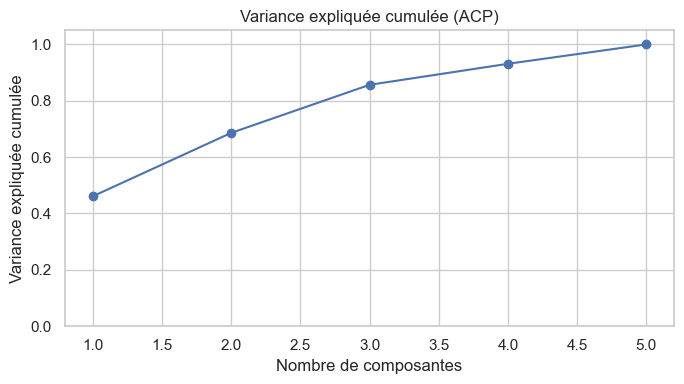

,CP1,CP2,CP3,CP4,CP5
temperature,-0.111837,0.893183,-0.110679,-0.255559,-0.334897
humidite,0.511848,-0.318837,-0.335179,-0.446119,-0.570076
precipitation,0.528219,0.231604,-0.360513,-0.192492,0.707335
ndvi,0.555518,0.203219,0.053320,0.766077,-0.245732
incident_1000,0.371334,0.075022,0.861738,-0.334275,0.046373


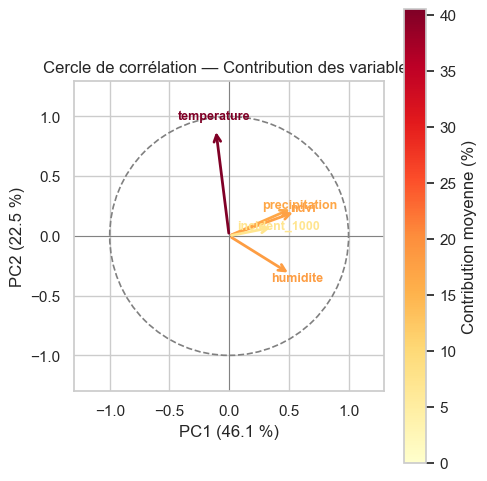

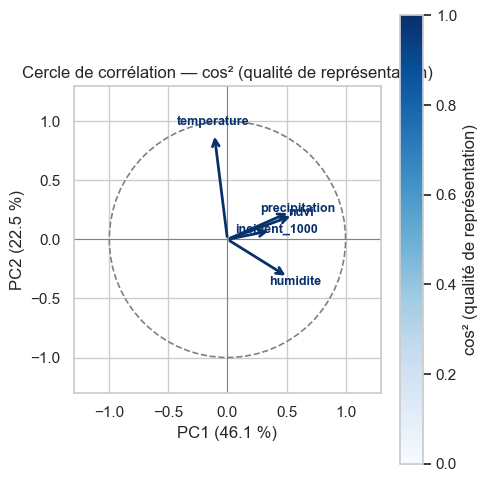

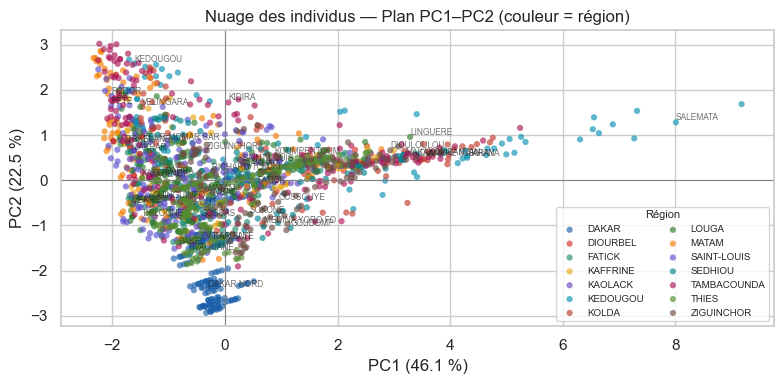

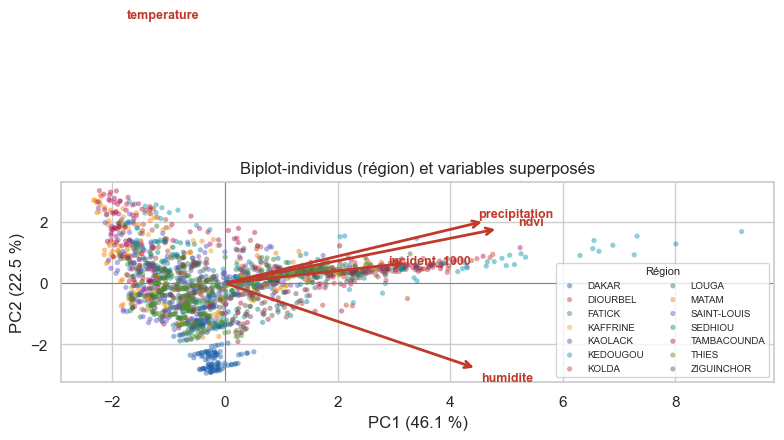

In [6]:
# D) ANALYSE FACTORIELLE (ACP)

# Variables imposees:
# temperature, humidite, precipitation, ndvi, incidence_1000

import matplotlib.cm as cm
import matplotlib.colors as mcolors

if "Incidence_1000" in df.columns and "incident_1000" not in df.columns:
    df["incident_1000"] = pd.to_numeric(df["Incidence_1000"], errors="coerce")

pca_vars = ["temperature", "humidite", "precipitation", "ndvi", "incident_1000"]
pca_vars = [c for c in pca_vars if c in df.columns]

if len(pca_vars) >= 3:
    has_district = "district" in df.columns
    has_region = "region" in df.columns
    keep_cols = pca_vars + (["district"] if has_district else []) + (["region"] if has_region else [])
    pca_data = df[keep_cols].dropna(subset=pca_vars).copy()
    labels_district = pca_data["district"].astype(str) if has_district else pca_data.index.astype(str)

    scaler_acp = StandardScaler()
    X_scaled = scaler_acp.fit_transform(pca_data[pca_vars])

    pca = PCA(n_components=min(5, len(pca_vars)))
    X_pca_all = pca.fit_transform(X_scaled)

    explained = pca.explained_variance_ratio_
    print("Variance expliquée par composante:")
    for i, v in enumerate(explained, start=1):
        print(f"CP{i}: {v:.3f}")

    plt.figure(figsize=(7, 4))
    plt.plot(range(1, len(explained) + 1), np.cumsum(explained), marker="o")
    plt.title("Variance expliquée cumulée (ACP)")
    plt.xlabel("Nombre de composantes")
    plt.ylabel("Variance expliquée cumulée")
    plt.ylim(0, 1.05)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    loadings_df = pd.DataFrame(
        pca.components_.T,
        columns=[f"CP{i}" for i in range(1, pca.n_components_ + 1)],
        index=pca_vars,
    )
    display(loadings_df)

    # ---- Plan PC1-PC2 uniquement pour les graphiques ----
    coords = X_pca_all[:, :2]                        # coordonnées individus
    loadings2 = pca.components_[:2].T                # coordonnées variables (p x 2)
    var_exp = explained[:2] * 100
    pc1_lbl = f"PC1 ({var_exp[0]:.1f} %)"
    pc2_lbl = f"PC2 ({var_exp[1]:.1f} %)"

    # Contribution moyenne de chaque variable sur PC1+PC2 (%)
    contrib = (loadings2 ** 2) * 100 / np.sum(loadings2 ** 2, axis=0)
    contrib_mean = contrib.mean(axis=1)

    # cos² = qualité de représentation sur le plan PC1–PC2
    norms2 = np.sum(loadings2 ** 2, axis=1, keepdims=True)
    cos2_sum = np.sum(loadings2 ** 2 / np.where(norms2 == 0, 1, norms2), axis=1)

    # Couleurs clusters K-Means si disponibles
    # Palette de 14 couleurs distinctes pour les régions
    _region_palette = [
        "#1a5fa8", "#d73027", "#1f8a70", "#e6a817", "#6b46c1",
        "#0891b2", "#c0392b", "#2e7d32", "#f57c00", "#5b4fcf",
        "#00838f", "#ad1457", "#558b2f", "#6d4c41"
    ]
    if has_region:
        _regions_sorted = sorted(pca_data["region"].astype(str).unique())
        region_colors = {r: _region_palette[i % len(_region_palette)] for i, r in enumerate(_regions_sorted)}
        ind_labels_cl = pca_data["region"].astype(str).tolist()
    else:
        _regions_sorted = []
        region_colors = {}
        ind_labels_cl = ['Inconnu'] * len(pca_data)
    default_color = "#888888"

    # --------------------------------------------------------
    # 1) Cercle de corrélation — CONTRIBUTION
    # --------------------------------------------------------
    cmap_c = cm.get_cmap('YlOrRd')
    norm_c = mcolors.Normalize(vmin=0, vmax=contrib_mean.max())
    fig1, ax1 = plt.subplots(figsize=(5, 5))
    ax1.add_patch(plt.Circle((0, 0), 1, color='grey', fill=False, lw=1.2, ls='--'))
    for i, var in enumerate(pca_vars):
        col = cmap_c(norm_c(contrib_mean[i]))
        ax1.annotate('', xy=(loadings2[i, 0], loadings2[i, 1]), xytext=(0, 0),
                     arrowprops=dict(arrowstyle='->', color=col, lw=2))
        ax1.text(loadings2[i, 0] * 1.12, loadings2[i, 1] * 1.12, var,
                 fontsize=9, ha='center', va='center', color=col, fontweight='bold')
    sm1 = cm.ScalarMappable(cmap=cmap_c, norm=norm_c); sm1.set_array([])
    plt.colorbar(sm1, ax=ax1, label='Contribution moyenne (%)')
    ax1.axhline(0, color='grey', lw=0.7); ax1.axvline(0, color='grey', lw=0.7)
    ax1.set_xlim(-1.3, 1.3); ax1.set_ylim(-1.3, 1.3)
    ax1.set_xlabel(pc1_lbl); ax1.set_ylabel(pc2_lbl)
    ax1.set_title('Cercle de corrélation — Contribution des variables')
    ax1.set_aspect('equal'); plt.tight_layout(); plt.show()

    # --------------------------------------------------------
    # 2) Cercle de corrélation — COS²
    # --------------------------------------------------------
    cmap_k = cm.get_cmap('Blues')
    norm_k = mcolors.Normalize(vmin=0, vmax=1)
    fig2, ax2 = plt.subplots(figsize=(5, 5))
    ax2.add_patch(plt.Circle((0, 0), 1, color='grey', fill=False, lw=1.2, ls='--'))
    for i, var in enumerate(pca_vars):
        col2 = cmap_k(norm_k(cos2_sum[i]))
        ax2.annotate('', xy=(loadings2[i, 0], loadings2[i, 1]), xytext=(0, 0),
                     arrowprops=dict(arrowstyle='->', color=col2, lw=2))
        ax2.text(loadings2[i, 0] * 1.12, loadings2[i, 1] * 1.12, var,
                 fontsize=9, ha='center', va='center', color=col2, fontweight='bold')
    sm2 = cm.ScalarMappable(cmap=cmap_k, norm=norm_k); sm2.set_array([])
    plt.colorbar(sm2, ax=ax2, label='cos² (qualité de représentation)')
    ax2.axhline(0, color='grey', lw=0.7); ax2.axvline(0, color='grey', lw=0.7)
    ax2.set_xlim(-1.3, 1.3); ax2.set_ylim(-1.3, 1.3)
    ax2.set_xlabel(pc1_lbl); ax2.set_ylabel(pc2_lbl)
    ax2.set_title('Cercle de corrélation — cos² (qualité de représentation)')
    ax2.set_aspect('equal'); plt.tight_layout(); plt.show()

    # --------------------------------------------------------
    # 3) Nuage des individus — Districts
    # --------------------------------------------------------
    fig3, ax3 = plt.subplots(figsize=(8, 4))
    for reg in _regions_sorted:
        col = region_colors[reg]
        mask = np.array([lbl == reg for lbl in ind_labels_cl])
        if mask.any():
            ax3.scatter(coords[mask, 0], coords[mask, 1],
                        color=col, label=reg, alpha=0.65, edgecolors='none', lw=0, s=20)
    if not has_region:
        ax3.scatter(coords[:, 0], coords[:, 1],
                    color=default_color, label='Inconnu', alpha=0.45, edgecolors='none', lw=0, s=14)
    step = max(1, len(pca_data) // 40)
    for idx in range(0, len(pca_data), step):
        ax3.text(coords[idx, 0], coords[idx, 1],
                 str(labels_district.iloc[idx])[:14],
                 fontsize=6, ha='left', va='bottom', alpha=0.65)
    ax3.axhline(0, color='grey', lw=0.7); ax3.axvline(0, color='grey', lw=0.7)
    ax3.set_xlabel(pc1_lbl); ax3.set_ylabel(pc2_lbl)
    ax3.set_title('Nuage des individus — Plan PC1–PC2 (couleur = région)')
    ax3.legend(title='Région', loc='best', fontsize=7, title_fontsize=8, ncol=2)
    plt.tight_layout(); plt.show()

    # --------------------------------------------------------
    # 4) Biplot — Individus + Variables superposés
    # --------------------------------------------------------
    scale = np.max(np.abs(coords)) / (np.max(np.abs(loadings2)) + 1e-9) * 0.85
    fig4, ax4 = plt.subplots(figsize=(8, 8))
    for reg in _regions_sorted:
        col = region_colors[reg]
        mask = np.array([lbl == reg for lbl in ind_labels_cl])
        if mask.any():
            ax4.scatter(coords[mask, 0], coords[mask, 1],
                        color=col, label=reg, alpha=0.45, edgecolors='none', lw=0, s=14)
    if not has_region:
        ax4.scatter(coords[:, 0], coords[:, 1],
                    color=default_color, label='Inconnu', alpha=0.35, edgecolors='none', lw=0, s=10)
    for i, var in enumerate(pca_vars):
        ax4.annotate('', xy=(loadings2[i, 0] * scale, loadings2[i, 1] * scale), xytext=(0, 0),
                     arrowprops=dict(arrowstyle='->', color='#c0392b', lw=2))
        ax4.text(loadings2[i, 0] * scale * 1.12, loadings2[i, 1] * scale * 1.12, var,
                 fontsize=9, color='#c0392b', fontweight='bold', ha='center', va='center')
    ax4.axhline(0, color='grey', lw=0.7); ax4.axvline(0, color='grey', lw=0.7)
    ax4.set_xlabel(pc1_lbl); ax4.set_ylabel(pc2_lbl)
    ax4.set_title('Biplot-individus (région) et variables superposés')
    ax4.legend(title='Région', loc='best', fontsize=7, title_fontsize=8, ncol=2)
    plt.tight_layout(); plt.show()

else:
    print("Variables insuffisantes pour l'ACP.")


## 07 — Clustering K-Means

Segmentation des observations en **3 groupes homogènes** de risque paludisme.

- Variables : incidence/1000, température, humidité, précipitations, NDVI
- Graphes exploratoires : méthode du coude + score de silhouette
- Clustering fixé à **k = 3** avec attribution de labels sémantiques selon l'incidence croissante
- Profils : **Faible risque** · **Risque Moyen** · **Risque Élevé**


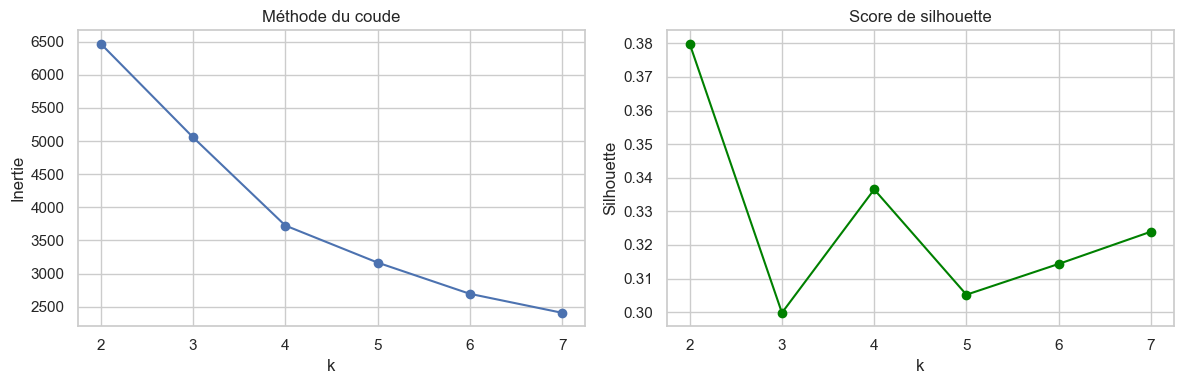

Nombre de clusters choisi : 3 (Faible / Moyen / Élevé)


,incident_1000,temperature,humidite,precipitation,ndvi
cluster_label,,,,,
Faible,0.34,30.10,35.46,0.76,0.24
Moyen,1.46,24.98,62.18,0.92,0.27
Élevé,11.97,27.22,81.45,8.59,0.53


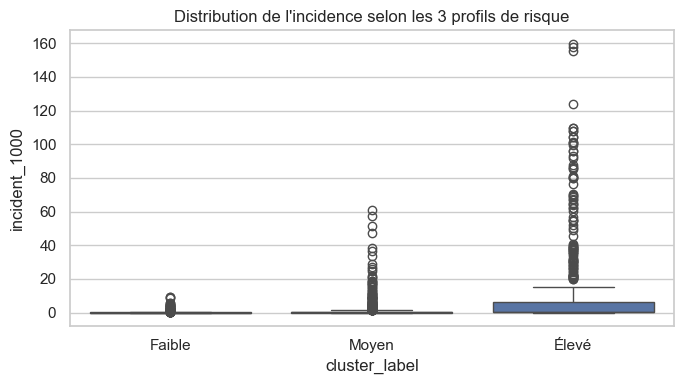

In [7]:
# E) ANALYSE NON SUPERVISEE (KMEANS)

# Variables imposees:
# incidence_1000, temperature, humidite, precipitation, ndvi

if "Incidence_1000" in df.columns and "incident_1000" not in df.columns:
    df["incident_1000"] = pd.to_numeric(df["Incidence_1000"], errors="coerce")

cluster_vars = ["incident_1000", "temperature", "humidite", "precipitation", "ndvi"]
cluster_vars = [c for c in cluster_vars if c in df.columns]

if len(cluster_vars) >= 3:
    X = df[cluster_vars].dropna().copy()
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)

    inertias = []
    silhouettes = []
    k_values = range(2, 8)

    for k in k_values:
        km = KMeans(n_clusters=k, random_state=42, n_init=20)
        labels = km.fit_predict(Xs)
        inertias.append(km.inertia_)
        silhouettes.append(silhouette_score(Xs, labels))

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(list(k_values), inertias, marker="o")
    ax[0].set_title("Méthode du coude")
    ax[0].set_xlabel("k")
    ax[0].set_ylabel("Inertie")

    ax[1].plot(list(k_values), silhouettes, marker="o", color="green")
    ax[1].set_title("Score de silhouette")
    ax[1].set_xlabel("k")
    ax[1].set_ylabel("Silhouette")
    plt.tight_layout()
    plt.show()

    # Clustering fixé à 3 profils sémantiques : Faible / Moyen / Élevé
    print("Nombre de clusters choisi : 3 (Faible / Moyen / Élevé)")
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
    labels = kmeans.fit_predict(Xs)

    # Réintégrer les clusters
    df_clustered = df.loc[X.index].copy()
    df_clustered["cluster"] = labels

    # Assigner des labels sémantiques selon l'incidence croissante
    inc_col = "incident_1000" if "incident_1000" in cluster_vars else cluster_vars[0]
    centers_mean = df_clustered.groupby("cluster")[cluster_vars].mean()
    sorted_idx = centers_mean[inc_col].sort_values().index.tolist()
    label_map = {sorted_idx[0]: "Faible", sorted_idx[1]: "Moyen", sorted_idx[2]: "Élevé"}
    df_clustered["cluster_label"] = df_clustered["cluster"].map(label_map)

    summary_cluster = df_clustered.groupby("cluster_label")[cluster_vars].mean().round(2)
    display(summary_cluster)

    if "incident_1000" in df_clustered.columns:
        plt.figure(figsize=(7, 4))
        sns.boxplot(data=df_clustered, x="cluster_label", y="incident_1000",
                    order=["Faible", "Moyen", "Élevé"])
        plt.title("Distribution de l'incidence selon les 3 profils de risque")
        plt.tight_layout()
        plt.show()
else:
    print("Variables insuffisantes pour le clustering.")


## 08 — Relations environnementales

Carte choroplèthe de l'incidence et analyse des facteurs environnementaux liés au paludisme.

- **Carte** : répartition géographique de l'incidence par région
- **Pluie** : relation précipitations → cas confirmés
- **Température** : relation température → cas confirmés
- **NDVI** : relation végétation → incidence/1000
- **Décès** : taux de mortalité paludisme
- **Hospitalisations** : taux d'hospitalisation



### Pluie — Paludisme

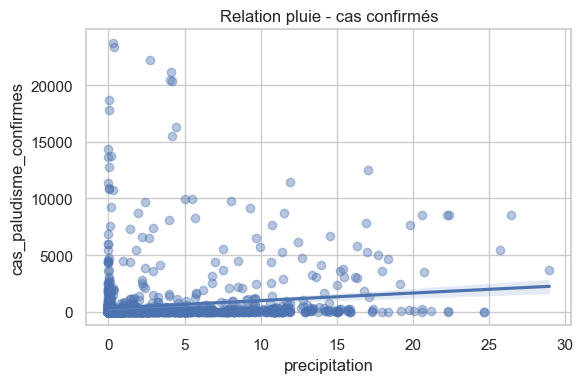

In [8]:
if {"precipitation", "cas_paludisme_confirmes"}.issubset(df.columns):
    plt.figure(figsize=(6, 4))
    sns.regplot(data=df, x="precipitation", y="cas_paludisme_confirmes", scatter_kws={"alpha": 0.4})
    plt.title("Relation pluie - cas confirmés")
    plt.tight_layout()
    plt.show()

### Température — Paludisme

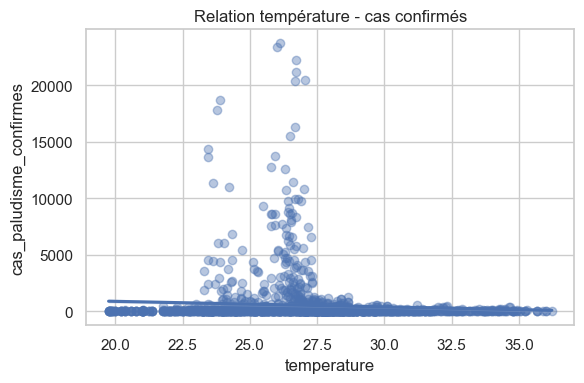

In [9]:
if {"temperature", "cas_paludisme_confirmes"}.issubset(df.columns):
    plt.figure(figsize=(6, 4))
    sns.regplot(data=df, x="temperature", y="cas_paludisme_confirmes", scatter_kws={"alpha": 0.4})
    plt.title("Relation température - cas confirmés")
    plt.tight_layout()
    plt.show()

### NDVI — Incidence du Paludisme

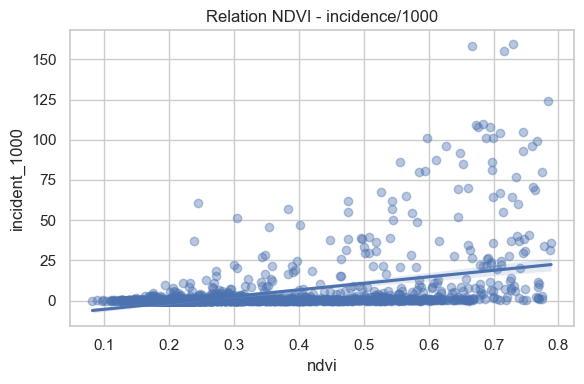

In [10]:
if {"ndvi", "incident_1000"}.issubset(df.columns):
    plt.figure(figsize=(6, 4))
    sns.regplot(data=df, x="ndvi", y="incident_1000", scatter_kws={"alpha": 0.4})
    plt.title("Relation NDVI - incidence/1000")
    plt.tight_layout()
    plt.show()

### Décès — Taux de mortalité paludisme

In [11]:
if {"deces_palu_total", "cas_paludisme_confirmes"}.issubset(df.columns):
    deces_total = df["deces_palu_total"].sum(skipna=True)
    cas_total = df["cas_paludisme_confirmes"].sum(skipna=True)
    taux_mortalite = (deces_total / cas_total * 100) if cas_total > 0 else np.nan
    print(f"Décès paludisme (total): {deces_total:,.0f}")
    print(f"Cas confirmés (total): {cas_total:,.0f}")
    print(f"Taux de mortalité paludisme: {taux_mortalite:.3f}%")

Décès paludisme (total): 742
Cas confirmés (total): 982,163
Taux de mortalité paludisme: 0.076%


### Hospitalisations

Hospitalisations (total): 574,831
Taux d'hospitalisation (hospitalisations/cas): 58.53%


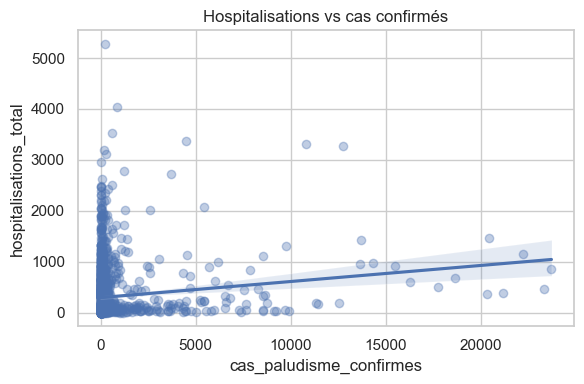

In [12]:
if {"hospitalisations_total", "cas_paludisme_confirmes"}.issubset(df.columns):
    hosp_total = df["hospitalisations_total"].sum(skipna=True)
    cas_total = df["cas_paludisme_confirmes"].sum(skipna=True)
    taux_hosp = (hosp_total / cas_total * 100) if cas_total > 0 else np.nan
    print(f"Hospitalisations (total): {hosp_total:,.0f}")
    print(f"Taux d'hospitalisation (hospitalisations/cas): {taux_hosp:.2f}%")

    plt.figure(figsize=(6, 4))
    sns.regplot(data=df, x="cas_paludisme_confirmes", y="hospitalisations_total", scatter_kws={"alpha": 0.35})
    plt.title("Hospitalisations vs cas confirmés")
    plt.tight_layout()
    plt.show()

## 09 — Série temporelle & Prévisions

Analyse temporelle et modèles de prédiction de l'incidence du paludisme.

- **Holt-Winters** : décomposition saisonnière + prévision simple 6 mois
- **Régression Linéaire** : baseline avec variables retardées (lags)
- **Random Forest** : modèle non-linéaire avec tuning temporel (GridSearchCV)
- **SARIMA** : modèle avancé de séries temporelles saisonnières

### Holt-Winters — Prévision simple

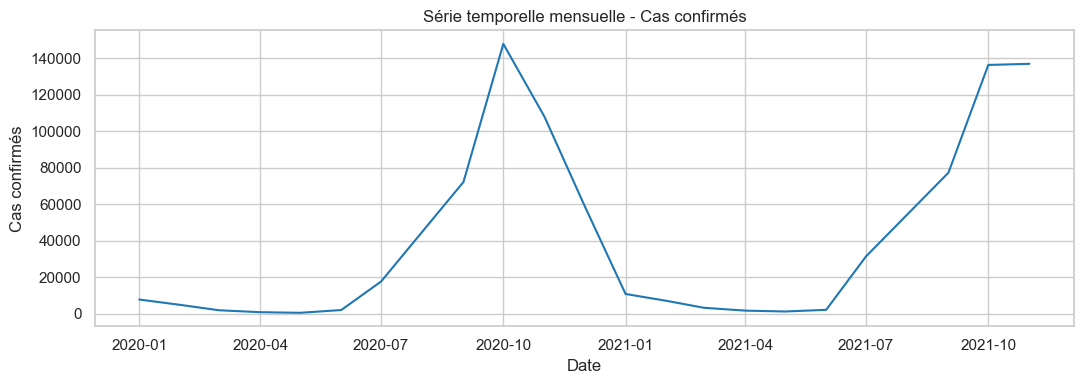

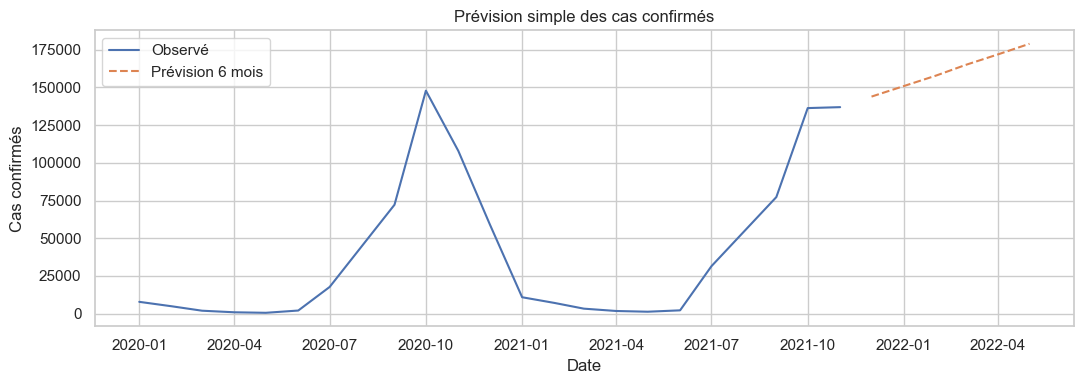

,date,prevision_cas
0,2021-12-01,143905.902575
1,2022-01-01,150907.805055
2,2022-02-01,157909.707536
3,2022-03-01,164911.610016
4,2022-04-01,171913.512496
5,2022-05-01,178915.414976


In [13]:

# F) ANALYSE SERIE TEMPORELLE (SIMPLE)

if "date" in df.columns and "cas_paludisme_confirmes" in df.columns:
    ts = (
        df.dropna(subset=["date"])
        .groupby("date")["cas_paludisme_confirmes"]
        .sum()
        .sort_index()
        .asfreq("MS")
    )

    if ts.notna().sum() == 0:
        print("Série temporelle vide après nettoyage des dates.")
    else:
        ts = ts.interpolate(method="linear")

        plt.figure(figsize=(11, 4))
        plt.plot(ts.index, ts.values, color="tab:blue")
        plt.title("Série temporelle mensuelle - Cas confirmés")
        plt.xlabel("Date")
        plt.ylabel("Cas confirmés")
        plt.tight_layout()
        plt.show()

        if len(ts.dropna()) >= 24:
            decomp = seasonal_decompose(ts, model="additive", period=12)
            decomp.plot()
            plt.suptitle("Décomposition saisonnière", y=1.02)
            plt.show()

        if len(ts.dropna()) >= 24:
            model = ExponentialSmoothing(ts, trend="add", seasonal="add", seasonal_periods=12)
        else:
            model = ExponentialSmoothing(ts, trend="add", seasonal=None)

        fit = model.fit(optimized=True)
        forecast = fit.forecast(6)

        plt.figure(figsize=(11, 4))
        plt.plot(ts.index, ts.values, label="Observé")
        plt.plot(forecast.index, forecast.values, label="Prévision 6 mois", linestyle="--")
        plt.title("Prévision simple des cas confirmés")
        plt.xlabel("Date")
        plt.ylabel("Cas confirmés")
        plt.legend()
        plt.tight_layout()
        plt.show()

        display(pd.DataFrame({"date": forecast.index, "prevision_cas": forecast.values}))
else:
    print("Variables 'date' et/ou 'cas_paludisme_confirmes' absentes.")

### Régression Linéaire Multiple (baseline)

Prédiction de l'incidence (`incident_1000`) à partir des variables climatiques et des lags temporels.

=== Regression Lineaire Multiple (avec variables retardees) ===
Type de split        : Temporel (80/20)
N observations       : 948
Groupe temporel      : district
Variables utilisees  : ['temperature', 'humidite', 'precipitation', 'ndvi', 'lag_1', 'lag_2', 'lag_3', 'lag_6', 'roll_mean_3', 'roll_mean_6']
R² (test)            : 0.8460
RMSE (test)          : 8.7415
MAE (test)           : 4.2113
sMAPE (test) %       : 94.42
R² CV                : -904.1008 ± 1116.7630

--- Baseline naive (lag_1) ---
R² baseline          : 0.8483
RMSE baseline        : 8.6750
MAE baseline         : 3.8463
sMAPE baseline       : 74.38


,coefficient
ndvi,10.084293
lag_1,1.138107
lag_2,-0.707949
precipitation,0.499507
roll_mean_6,-0.417889
lag_3,0.281647
roll_mean_3,0.237268
lag_6,0.189443
temperature,-0.081250
humidite,-0.020463


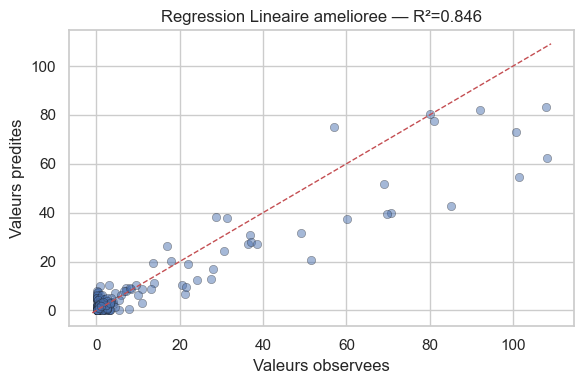

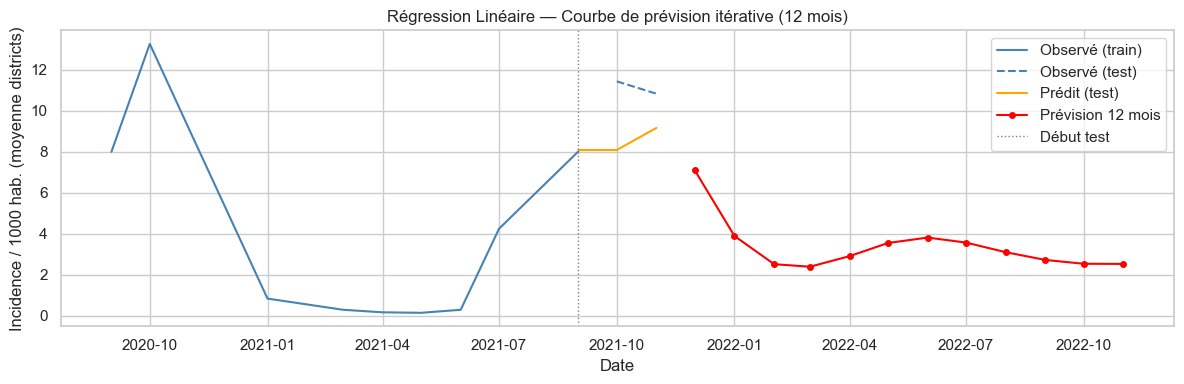

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Variables predictives (climatiques + environnementales + lags temporels)
base_features = ["temperature", "humidite", "precipitation", "ndvi"]
target = "incident_1000"


def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true) + np.abs(y_pred)
    denom = np.where(denom == 0, 1e-8, denom)
    return float(np.mean(2.0 * np.abs(y_pred - y_true) / denom) * 100.0)


def build_supervised_incidence_frame(df_source, base_features, target):
    required = [target, "date"]
    if not set(required).issubset(df_source.columns):
        return None, [], None

    work = df_source.copy()
    candidate_group_cols = [c for c in ["district", "district_sanitaire", "region"] if c in work.columns]
    group_col = candidate_group_cols[0] if candidate_group_cols else None

    cols = ["date", target] + [c for c in base_features if c in work.columns]
    if group_col:
        cols.append(group_col)

    model_df = work[cols].dropna(subset=["date", target]).copy()
    model_df = model_df.sort_values(([group_col] if group_col else []) + ["date"]).reset_index(drop=True)

    if group_col:
        grouped_target = model_df.groupby(group_col)[target]
        model_df["lag_1"] = grouped_target.shift(1)
        model_df["lag_2"] = grouped_target.shift(2)
        model_df["lag_3"] = grouped_target.shift(3)
        model_df["lag_6"] = grouped_target.shift(6)
        model_df["roll_mean_3"] = grouped_target.shift(1).rolling(3).mean().reset_index(level=0, drop=True)
        model_df["roll_mean_6"] = grouped_target.shift(1).rolling(6).mean().reset_index(level=0, drop=True)
    else:
        shifted = model_df[target].shift(1)
        model_df["lag_1"] = shifted
        model_df["lag_2"] = model_df[target].shift(2)
        model_df["lag_3"] = model_df[target].shift(3)
        model_df["lag_6"] = model_df[target].shift(6)
        model_df["roll_mean_3"] = shifted.rolling(3).mean()
        model_df["roll_mean_6"] = shifted.rolling(6).mean()

    feature_cols = [c for c in base_features if c in model_df.columns] + [
        "lag_1", "lag_2", "lag_3", "lag_6", "roll_mean_3", "roll_mean_6"
    ]
    model_df = model_df.dropna(subset=feature_cols + [target]).copy()
    model_df = model_df.sort_values("date").reset_index(drop=True)
    return model_df, feature_cols, group_col


data_lr, features_lr, group_col_lr = build_supervised_incidence_frame(df, base_features, target)

if data_lr is not None and len(features_lr) >= 4 and len(data_lr) >= 30:
    split_idx = max(int(len(data_lr) * 0.8), 24)
    split_idx = min(split_idx, len(data_lr) - 6)

    train_df = data_lr.iloc[:split_idx].copy()
    test_df = data_lr.iloc[split_idx:].copy()

    X_train = train_df[features_lr]
    y_train = train_df[target]
    X_test = test_df[features_lr]
    y_test = test_df[target]

    lr = LinearRegression()
    lr.fit(X_train, y_train)
    y_pred_lr = np.clip(lr.predict(X_test), a_min=0, a_max=None)

    rmse_lr = mean_squared_error(y_test, y_pred_lr) ** 0.5
    mae_lr = mean_absolute_error(y_test, y_pred_lr)
    r2_lr = r2_score(y_test, y_pred_lr)
    smape_lr = smape(y_test, y_pred_lr)

    n_splits = min(5, max(2, len(data_lr) // 24))
    cv = TimeSeriesSplit(n_splits=n_splits)
    cv_scores_lr = cross_val_score(lr, data_lr[features_lr], data_lr[target], cv=cv, scoring="r2")

    baseline_pred = np.clip(X_test["lag_1"].to_numpy(dtype=float), a_min=0, a_max=None)
    baseline_rmse_lr = mean_squared_error(y_test, baseline_pred) ** 0.5
    baseline_mae_lr = mean_absolute_error(y_test, baseline_pred)
    baseline_r2_lr = r2_score(y_test, baseline_pred)
    baseline_smape_lr = smape(y_test, baseline_pred)

    print("=== Regression Lineaire Multiple (avec variables retardees) ===")
    print("Type de split        : Temporel (80/20)")
    print(f"N observations       : {len(data_lr)}")
    print(f"Groupe temporel      : {group_col_lr if group_col_lr else 'Aucun'}")
    print(f"Variables utilisees  : {features_lr}")
    print(f"R² (test)            : {r2_lr:.4f}")
    print(f"RMSE (test)          : {rmse_lr:.4f}")
    print(f"MAE (test)           : {mae_lr:.4f}")
    print(f"sMAPE (test) %       : {smape_lr:.2f}")
    print(f"R² CV                : {cv_scores_lr.mean():.4f} ± {cv_scores_lr.std():.4f}")

    print("\n--- Baseline naive (lag_1) ---")
    print(f"R² baseline          : {baseline_r2_lr:.4f}")
    print(f"RMSE baseline        : {baseline_rmse_lr:.4f}")
    print(f"MAE baseline         : {baseline_mae_lr:.4f}")
    print(f"sMAPE baseline       : {baseline_smape_lr:.2f}")

    coef_table_lr = (
        pd.Series(lr.coef_, index=features_lr)
        .sort_values(key=np.abs, ascending=False)
        .rename("coefficient")
        .to_frame()
    )
    display(coef_table_lr)

    plt.figure(figsize=(6, 4))
    plt.scatter(y_test, y_pred_lr, alpha=0.5, edgecolors="k", linewidths=0.4)
    lim = [min(y_test.min(), y_pred_lr.min()) - 1, max(y_test.max(), y_pred_lr.max()) + 1]
    plt.plot(lim, lim, "r--", linewidth=1)
    plt.xlabel("Valeurs observees")
    plt.ylabel("Valeurs predites")
    plt.title(f"Regression Lineaire amelioree — R²={r2_lr:.3f}")
    plt.tight_layout()
    plt.show()

    # --- Prévision itérative 12 mois (Régression Linéaire) ---
    from collections import deque as _deque

    forecast_dates_lr = []
    forecast_vals_lr = []
    last_date_lr = data_lr["date"].max()

    if group_col_lr:
        districts_lr = data_lr[group_col_lr].unique()
        district_state_lr = {}
        for d in districts_lr:
            d_data = data_lr[data_lr[group_col_lr] == d].sort_values("date")
            last_vals = list(d_data[target].values[-6:])
            last_row = d_data.iloc[-1]
            clim = {f: float(last_row[f]) for f in base_features if f in d_data.columns}
            district_state_lr[d] = {"history": _deque(last_vals, maxlen=6), "climate": clim}
    else:
        d_data = data_lr.sort_values("date")
        last_vals = list(d_data[target].values[-6:])
        last_row = d_data.iloc[-1]
        clim = {f: float(last_row[f]) for f in base_features if f in d_data.columns}
        district_state_lr = {"_global": {"history": _deque(last_vals, maxlen=6), "climate": clim}}

    cur_month_lr, cur_year_lr = last_date_lr.month, last_date_lr.year

    for _ in range(12):
        cur_month_lr += 1
        if cur_month_lr > 12:
            cur_month_lr = 1
            cur_year_lr += 1
        fc_date = pd.Timestamp(year=cur_year_lr, month=cur_month_lr, day=1)
        forecast_dates_lr.append(fc_date)

        preds_step = []
        for d, st in district_state_lr.items():
            h = list(st["history"])
            n = len(h)
            lag_1 = h[-1] if n >= 1 else 0.0
            lag_2 = h[-2] if n >= 2 else lag_1
            lag_3 = h[-3] if n >= 3 else lag_2
            lag_6 = h[-6] if n >= 6 else h[0]
            roll_3 = float(np.mean(h[-3:])) if n >= 3 else float(np.mean(h))
            roll_6 = float(np.mean(h[-6:])) if n >= 6 else float(np.mean(h))
            feat_vals = {f: st["climate"].get(f, 0.0) for f in base_features if f in features_lr}
            feat_vals.update({"lag_1": lag_1, "lag_2": lag_2, "lag_3": lag_3,
                               "lag_6": lag_6, "roll_mean_3": roll_3, "roll_mean_6": roll_6})
            X_fc = pd.DataFrame([[feat_vals.get(f, 0.0) for f in features_lr]], columns=features_lr)
            pred_d = float(np.clip(lr.predict(X_fc)[0], 0, None))
            preds_step.append(pred_d)
            st["history"].append(pred_d)

        forecast_vals_lr.append(float(np.mean(preds_step)))

    hist_agg_lr = data_lr.groupby("date")[target].mean()
    split_date_lr = data_lr.iloc[split_idx - 1]["date"]
    train_idx_lr = hist_agg_lr.index <= split_date_lr
    test_idx_lr = hist_agg_lr.index > split_date_lr

    test_df_copy_lr = test_df.copy()
    test_df_copy_lr["pred_lr"] = y_pred_lr
    test_pred_agg_lr = test_df_copy_lr.groupby("date")["pred_lr"].mean()

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(hist_agg_lr.index[train_idx_lr], hist_agg_lr[train_idx_lr],
            color="steelblue", linewidth=1.5, label="Observé (train)")
    ax.plot(hist_agg_lr.index[test_idx_lr], hist_agg_lr[test_idx_lr],
            color="steelblue", linestyle="--", linewidth=1.5, label="Observé (test)")
    ax.plot(test_pred_agg_lr.index, test_pred_agg_lr.values,
            color="orange", linewidth=1.5, label="Prédit (test)")
    ax.plot(forecast_dates_lr, forecast_vals_lr,
            color="red", marker="o", markersize=4, linewidth=1.5, label="Prévision 12 mois")
    ax.axvline(x=test_df["date"].min(), color="gray", linestyle=":", linewidth=1, label="Début test")
    ax.set_title("Régression Linéaire — Courbe de prévision itérative (12 mois)")
    ax.set_xlabel("Date")
    ax.set_ylabel("Incidence / 1000 hab. (moyenne districts)")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Variables insuffisantes pour une regression temporelle amelioree.")


### Random Forest Regressor

Modèle non-linéaire avec importance des variables et optimisation par validation croisée temporelle.

=== Random Forest Regressor (avec lags + tuning temporel) ===
Type de split        : Temporel (80/20)
N observations       : 948
Groupe temporel      : district
Variables utilisees  : ['temperature', 'humidite', 'precipitation', 'ndvi', 'lag_1', 'lag_2', 'lag_3', 'lag_6', 'roll_mean_3', 'roll_mean_6']
Meilleurs parametres : {'max_depth': None, 'max_features': None, 'min_samples_leaf': 4, 'n_estimators': 200}
R² (test)            : 0.9350
RMSE (test)          : 5.6763
MAE (test)           : 2.4251
sMAPE (test) %       : 42.76
R² CV (train)        : -19.7522 ± 27.8247

--- Baseline naive (lag_1) ---
R² baseline          : 0.8483
RMSE baseline        : 8.6750
MAE baseline         : 3.8463
sMAPE baseline       : 74.38

--- Comparaison des modeles ---
Modele                               R²       RMSE        MAE
Regression Lineaire + lags       0.8460     8.7415     4.2113
Random Forest + lags             0.9350     5.6763     2.4251


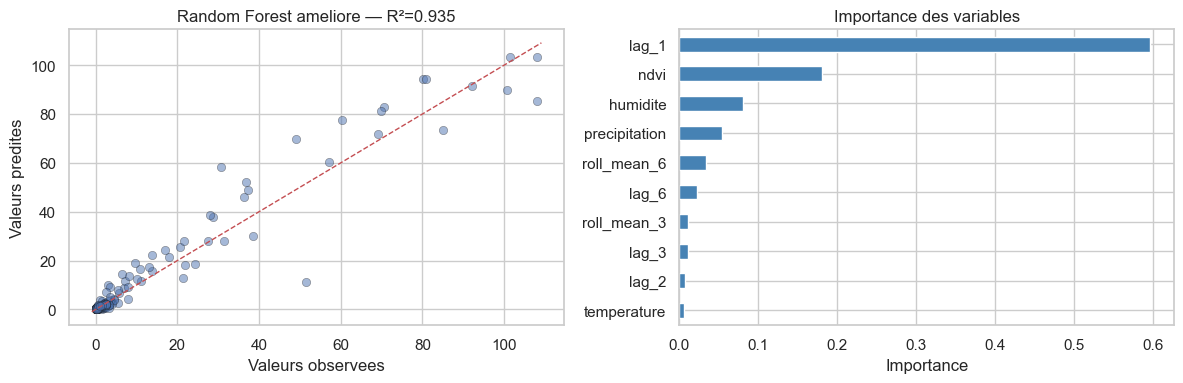

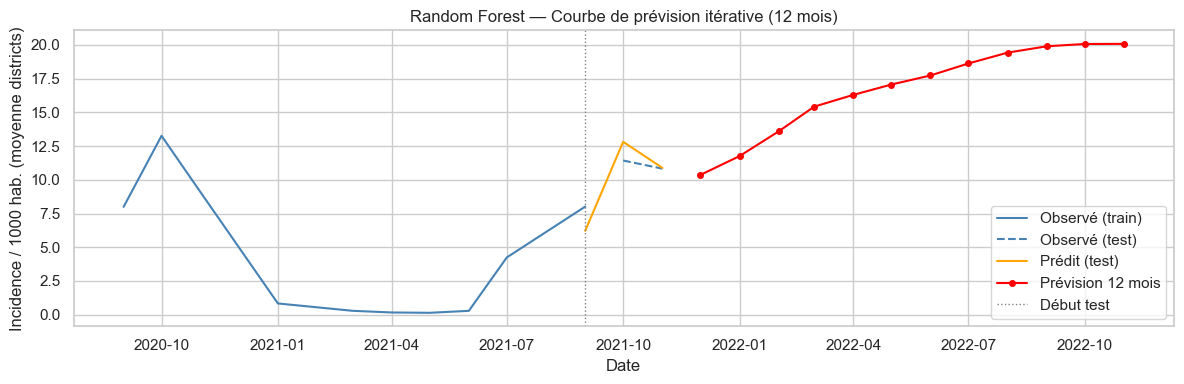

In [15]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

base_features = ["temperature", "humidite", "precipitation", "ndvi"]
target = "incident_1000"


def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true) + np.abs(y_pred)
    denom = np.where(denom == 0, 1e-8, denom)
    return float(np.mean(2.0 * np.abs(y_pred - y_true) / denom) * 100.0)


def build_supervised_incidence_frame(df_source, base_features, target):
    required = [target, "date"]
    if not set(required).issubset(df_source.columns):
        return None, [], None

    work = df_source.copy()
    candidate_group_cols = [c for c in ["district", "district_sanitaire", "region"] if c in work.columns]
    group_col = candidate_group_cols[0] if candidate_group_cols else None

    cols = ["date", target] + [c for c in base_features if c in work.columns]
    if group_col:
        cols.append(group_col)

    model_df = work[cols].dropna(subset=["date", target]).copy()
    model_df = model_df.sort_values(([group_col] if group_col else []) + ["date"]).reset_index(drop=True)

    if group_col:
        grouped_target = model_df.groupby(group_col)[target]
        model_df["lag_1"] = grouped_target.shift(1)
        model_df["lag_2"] = grouped_target.shift(2)
        model_df["lag_3"] = grouped_target.shift(3)
        model_df["lag_6"] = grouped_target.shift(6)
        model_df["roll_mean_3"] = grouped_target.shift(1).rolling(3).mean().reset_index(level=0, drop=True)
        model_df["roll_mean_6"] = grouped_target.shift(1).rolling(6).mean().reset_index(level=0, drop=True)
    else:
        shifted = model_df[target].shift(1)
        model_df["lag_1"] = shifted
        model_df["lag_2"] = model_df[target].shift(2)
        model_df["lag_3"] = model_df[target].shift(3)
        model_df["lag_6"] = model_df[target].shift(6)
        model_df["roll_mean_3"] = shifted.rolling(3).mean()
        model_df["roll_mean_6"] = shifted.rolling(6).mean()

    feature_cols = [c for c in base_features if c in model_df.columns] + [
        "lag_1", "lag_2", "lag_3", "lag_6", "roll_mean_3", "roll_mean_6"
    ]
    model_df = model_df.dropna(subset=feature_cols + [target]).copy()
    model_df = model_df.sort_values("date").reset_index(drop=True)
    return model_df, feature_cols, group_col


data_rf, features_rf, group_col_rf = build_supervised_incidence_frame(df, base_features, target)

if data_rf is not None and len(features_rf) >= 4 and len(data_rf) >= 30:
    split_idx = max(int(len(data_rf) * 0.8), 24)
    split_idx = min(split_idx, len(data_rf) - 6)

    train_df = data_rf.iloc[:split_idx].copy()
    test_df = data_rf.iloc[split_idx:].copy()

    X_train = train_df[features_rf]
    y_train = train_df[target]
    X_test = test_df[features_rf]
    y_test = test_df[target]

    n_splits = min(5, max(2, len(train_df) // 24))
    cv = TimeSeriesSplit(n_splits=n_splits)

    param_grid = {
        "n_estimators": [200, 400],
        "max_depth": [6, None],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", None],
    }

    rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)
    grid = GridSearchCV(
        estimator=rf_base,
        param_grid=param_grid,
        scoring="r2",
        cv=cv,
        n_jobs=-1,
        refit=True
    )
    grid.fit(X_train, y_train)
    rf = grid.best_estimator_

    y_pred_rf = np.clip(rf.predict(X_test), a_min=0, a_max=None)
    rmse_rf = mean_squared_error(y_test, y_pred_rf) ** 0.5
    mae_rf = mean_absolute_error(y_test, y_pred_rf)
    r2_rf = r2_score(y_test, y_pred_rf)
    smape_rf = smape(y_test, y_pred_rf)

    cv_scores = grid.cv_results_["mean_test_score"][grid.best_index_]
    cv_std = grid.cv_results_["std_test_score"][grid.best_index_]

    baseline_pred = np.clip(X_test["lag_1"].to_numpy(dtype=float), a_min=0, a_max=None)
    baseline_rmse_rf = mean_squared_error(y_test, baseline_pred) ** 0.5
    baseline_mae_rf = mean_absolute_error(y_test, baseline_pred)
    baseline_r2_rf = r2_score(y_test, baseline_pred)
    baseline_smape_rf = smape(y_test, baseline_pred)

    print("=== Random Forest Regressor (avec lags + tuning temporel) ===")
    print("Type de split        : Temporel (80/20)")
    print(f"N observations       : {len(data_rf)}")
    print(f"Groupe temporel      : {group_col_rf if group_col_rf else 'Aucun'}")
    print(f"Variables utilisees  : {features_rf}")
    print(f"Meilleurs parametres : {grid.best_params_}")
    print(f"R² (test)            : {r2_rf:.4f}")
    print(f"RMSE (test)          : {rmse_rf:.4f}")
    print(f"MAE (test)           : {mae_rf:.4f}")
    print(f"sMAPE (test) %       : {smape_rf:.2f}")
    print(f"R² CV (train)        : {cv_scores:.4f} ± {cv_std:.4f}")

    print("\n--- Baseline naive (lag_1) ---")
    print(f"R² baseline          : {baseline_r2_rf:.4f}")
    print(f"RMSE baseline        : {baseline_rmse_rf:.4f}")
    print(f"MAE baseline         : {baseline_mae_rf:.4f}")
    print(f"sMAPE baseline       : {baseline_smape_rf:.2f}")

    if "r2_lr" in globals() and "rmse_lr" in globals() and "mae_lr" in globals():
        print("\n--- Comparaison des modeles ---")
        print(f"{'Modele':<30} {'R²':>8} {'RMSE':>10} {'MAE':>10}")
        print(f"{'Regression Lineaire + lags':<30} {r2_lr:>8.4f} {rmse_lr:>10.4f} {mae_lr:>10.4f}")
        print(f"{'Random Forest + lags':<30} {r2_rf:>8.4f} {rmse_rf:>10.4f} {mae_rf:>10.4f}")

    importances = pd.Series(rf.feature_importances_, index=features_rf).sort_values(ascending=True)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].scatter(y_test, y_pred_rf, alpha=0.5, edgecolors="k", linewidths=0.4)
    lim = [min(y_test.min(), y_pred_rf.min()) - 1, max(y_test.max(), y_pred_rf.max()) + 1]
    axes[0].plot(lim, lim, "r--", linewidth=1)
    axes[0].set_xlabel("Valeurs observees")
    axes[0].set_ylabel("Valeurs predites")
    axes[0].set_title(f"Random Forest ameliore — R²={r2_rf:.3f}")

    importances.plot(kind="barh", ax=axes[1], color="steelblue")
    axes[1].set_title("Importance des variables")
    axes[1].set_xlabel("Importance")

    plt.tight_layout()
    plt.show()

    # --- Prévision itérative 12 mois (Random Forest) ---
    from collections import deque as _deque

    forecast_dates_rf = []
    forecast_vals_rf = []
    last_date_rf = data_rf["date"].max()

    if group_col_rf:
        districts_rf = data_rf[group_col_rf].unique()
        district_state_rf = {}
        for d in districts_rf:
            d_data = data_rf[data_rf[group_col_rf] == d].sort_values("date")
            last_vals = list(d_data[target].values[-6:])
            last_row = d_data.iloc[-1]
            clim = {f: float(last_row[f]) for f in base_features if f in d_data.columns}
            district_state_rf[d] = {"history": _deque(last_vals, maxlen=6), "climate": clim}
    else:
        d_data = data_rf.sort_values("date")
        last_vals = list(d_data[target].values[-6:])
        last_row = d_data.iloc[-1]
        clim = {f: float(last_row[f]) for f in base_features if f in d_data.columns}
        district_state_rf = {"_global": {"history": _deque(last_vals, maxlen=6), "climate": clim}}

    cur_month_rf, cur_year_rf = last_date_rf.month, last_date_rf.year

    for _ in range(12):
        cur_month_rf += 1
        if cur_month_rf > 12:
            cur_month_rf = 1
            cur_year_rf += 1
        fc_date = pd.Timestamp(year=cur_year_rf, month=cur_month_rf, day=1)
        forecast_dates_rf.append(fc_date)

        preds_step = []
        for d, st in district_state_rf.items():
            h = list(st["history"])
            n = len(h)
            lag_1 = h[-1] if n >= 1 else 0.0
            lag_2 = h[-2] if n >= 2 else lag_1
            lag_3 = h[-3] if n >= 3 else lag_2
            lag_6 = h[-6] if n >= 6 else h[0]
            roll_3 = float(np.mean(h[-3:])) if n >= 3 else float(np.mean(h))
            roll_6 = float(np.mean(h[-6:])) if n >= 6 else float(np.mean(h))
            feat_vals = {f: st["climate"].get(f, 0.0) for f in base_features if f in features_rf}
            feat_vals.update({"lag_1": lag_1, "lag_2": lag_2, "lag_3": lag_3,
                               "lag_6": lag_6, "roll_mean_3": roll_3, "roll_mean_6": roll_6})
            X_fc = pd.DataFrame([[feat_vals.get(f, 0.0) for f in features_rf]], columns=features_rf)
            pred_d = float(np.clip(rf.predict(X_fc)[0], 0, None))
            preds_step.append(pred_d)
            st["history"].append(pred_d)

        forecast_vals_rf.append(float(np.mean(preds_step)))

    hist_agg_rf = data_rf.groupby("date")[target].mean()
    split_date_rf = data_rf.iloc[split_idx - 1]["date"]
    train_idx_rf = hist_agg_rf.index <= split_date_rf
    test_idx_rf = hist_agg_rf.index > split_date_rf

    test_df_copy_rf = test_df.copy()
    test_df_copy_rf["pred_rf"] = y_pred_rf
    test_pred_agg_rf = test_df_copy_rf.groupby("date")["pred_rf"].mean()

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(hist_agg_rf.index[train_idx_rf], hist_agg_rf[train_idx_rf],
            color="steelblue", linewidth=1.5, label="Observé (train)")
    ax.plot(hist_agg_rf.index[test_idx_rf], hist_agg_rf[test_idx_rf],
            color="steelblue", linestyle="--", linewidth=1.5, label="Observé (test)")
    ax.plot(test_pred_agg_rf.index, test_pred_agg_rf.values,
            color="orange", linewidth=1.5, label="Prédit (test)")
    ax.plot(forecast_dates_rf, forecast_vals_rf,
            color="red", marker="o", markersize=4, linewidth=1.5, label="Prévision 12 mois")
    ax.axvline(x=test_df["date"].min(), color="gray", linestyle=":", linewidth=1, label="Début test")
    ax.set_title("Random Forest — Courbe de prévision itérative (12 mois)")
    ax.set_xlabel("Date")
    ax.set_ylabel("Incidence / 1000 hab. (moyenne districts)")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Variables insuffisantes pour Random Forest ameliore.")


### SARIMA — Prévision temporelle avancée

Modèle SARIMA (Seasonal ARIMA) pour capturer tendance et saisonnalité mensuelle avec évaluation rolling one-step-ahead.

=== Test ADF (stationnarite sur log1p) ===
Statistique ADF : -3.9145
p-value         : 0.0019
Serie stationnaire : Oui

Meilleur SARIMA: order=(1, 1, 0), seasonal_order=(0, 1, 1, 12)
AIC : 6.00
BIC : nan

=== SARIMA — Performance sur test ===
R²                  : 0.7382
RMSE                : 1.28
MAE                 : 0.99
sMAPE (%)           : 27.93

--- Baseline naive saisonniere ---
R² baseline         : 0.8725
RMSE baseline       : 0.90
MAE baseline        : 0.77
sMAPE baseline      : 20.98

--- Evaluation rolling one-step-ahead ---
RMSE rolling        : 1.26
MAE rolling         : 0.89
sMAPE rolling       : 73.67


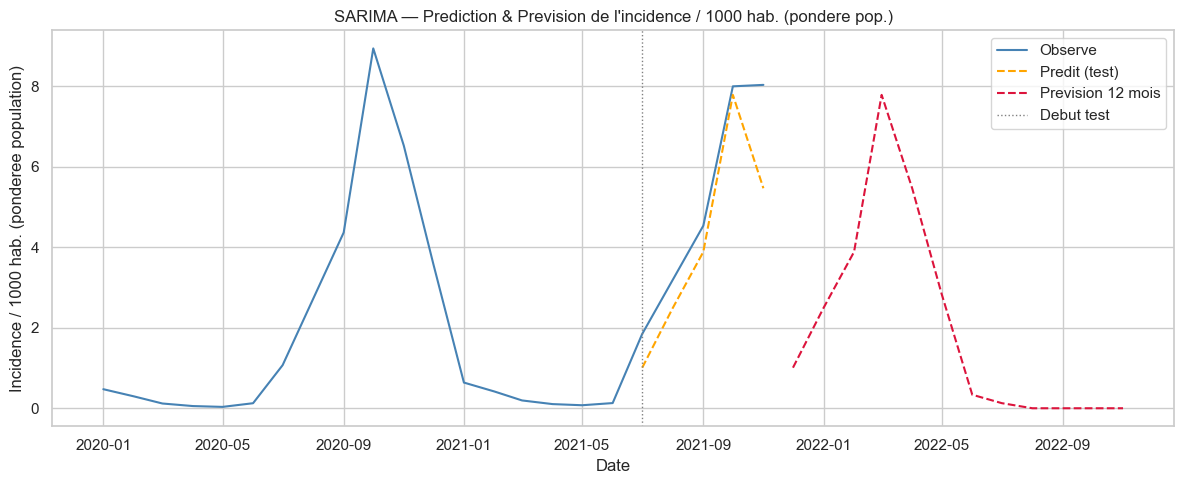


Previsions SARIMA (horizon disponible, bornees a >= 0) :


,date,prevision_incident_1000
0,2021-12-01,1.0074
1,2022-01-01,2.4901
2,2022-02-01,3.8835
3,2022-03-01,7.7819
4,2022-04-01,5.4631
5,2022-05-01,2.8309
6,2022-06-01,0.3354
7,2022-07-01,0.1265
8,2022-08-01,0.0000
9,2022-09-01,0.0000


In [16]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true) + np.abs(y_pred)
    denom = np.where(denom == 0, 1e-8, denom)
    return float(np.mean(2.0 * np.abs(y_pred - y_true) / denom) * 100.0)


if "date" in df.columns and "incident_1000" in df.columns:
    # Incidence pondérée par population = incidence nationale réelle (vectorisé)
    _df_sarima = df.dropna(subset=["date", "incident_1000", "population"]).copy()
    _df_sarima["_wt_inc"] = _df_sarima["incident_1000"] * _df_sarima["population"]
    _agg = _df_sarima.groupby("date")[["_wt_inc", "population"]].sum()
    ts_s = (
        (_agg["_wt_inc"] / _agg["population"])
        .sort_index()
        .asfreq("MS")
        .interpolate(method="linear")
    )

    if len(ts_s.dropna()) < 12:
        print("Donnees temporelles insuffisantes pour SARIMA.")
    else:
        ts_log = np.log1p(ts_s.clip(lower=0))

        adf_result = adfuller(ts_log.dropna())
        print("=== Test ADF (stationnarite sur log1p) ===")
        print(f"Statistique ADF : {adf_result[0]:.4f}")
        print(f"p-value         : {adf_result[1]:.4f}")
        print("Serie stationnaire :", "Oui" if adf_result[1] < 0.05 else "Non -> differenciation necessaire")

        n = len(ts_log)
        split = int(n * 0.8)
        split = min(max(split, 12), n - 3)
        train_s = ts_log.iloc[:split]
        test_s = ts_log.iloc[split:]

        has_strong_seasonality_window = len(train_s) >= 18
        order_grid = [(1, 1, 0), (1, 1, 1), (2, 1, 1)]
        seasonal_grid = [(0, 1, 1, 12), (1, 1, 0, 12), (1, 1, 1, 12)] if has_strong_seasonality_window else [(0, 0, 0, 0)]

        if not has_strong_seasonality_window:
            print("Attention: historique court, la composante saisonniere est desactivee pour eviter un faux sur-apprentissage.")

        best_fit = None
        best_cfg = None
        best_aic = np.inf

        for od in order_grid:
            for sod in seasonal_grid:
                try:
                    mdl = SARIMAX(
                        train_s,
                        order=od,
                        seasonal_order=sod,
                        enforce_stationarity=False,
                        enforce_invertibility=False,
                    )
                    fit_try = mdl.fit(disp=False)
                    if np.isfinite(fit_try.aic) and fit_try.aic < best_aic:
                        best_aic = fit_try.aic
                        best_fit = fit_try
                        best_cfg = (od, sod)
                except Exception:
                    continue

        if best_fit is None:
            print("Echec de calibration SARIMA sur la grille testee.")
        else:
            print(f"\nMeilleur SARIMA: order={best_cfg[0]}, seasonal_order={best_cfg[1]}")
            print(f"AIC : {best_fit.aic:.2f}")
            print(f"BIC : {best_fit.bic:.2f}")

            pred_test_log = best_fit.predict(start=test_s.index[0], end=test_s.index[-1])
            pred_test = pd.Series(np.expm1(np.asarray(pred_test_log)).clip(min=0), index=test_s.index)
            y_test_sarima = ts_s.loc[test_s.index]

            rmse_sarima = mean_squared_error(y_test_sarima, pred_test) ** 0.5
            mae_sarima = mean_absolute_error(y_test_sarima, pred_test)
            r2_sarima = r2_score(y_test_sarima, pred_test)
            smape_sarima = smape(y_test_sarima, pred_test)

            if has_strong_seasonality_window:
                seasonal_naive = ts_s.shift(12).reindex(test_s.index)
                if seasonal_naive.isna().any():
                    seasonal_naive = seasonal_naive.fillna(ts_s.iloc[:split].mean())
                baseline_label = "Baseline naive saisonniere"
            else:
                seasonal_naive = pd.Series(ts_s.iloc[:split].iloc[-1], index=test_s.index)
                baseline_label = "Baseline naive dernier point"

            naive_pred = seasonal_naive.to_numpy(dtype=float)

            baseline_rmse_sarima = mean_squared_error(y_test_sarima, naive_pred) ** 0.5
            baseline_mae_sarima = mean_absolute_error(y_test_sarima, naive_pred)
            baseline_r2_sarima = r2_score(y_test_sarima, naive_pred)
            baseline_smape_sarima = smape(y_test_sarima, naive_pred)

            future_log = best_fit.forecast(steps=12)
            future_values = np.expm1(np.asarray(future_log)).clip(min=0)
            forecast_sarima = pd.Series(
                future_values,
                index=pd.date_range(start=ts_s.index[-1] + pd.DateOffset(months=1), periods=len(future_values), freq="MS")
            )

            rolling_errors = []
            min_train_size = 12
            for end_idx in range(min_train_size, len(ts_log) - 1):
                train_fold = ts_log.iloc[:end_idx]
                actual_point = ts_s.iloc[end_idx:end_idx + 1]
                seasonal_order_fold = best_cfg[1] if len(train_fold) >= 18 else (0, 0, 0, 0)
                try:
                    fold_model = SARIMAX(
                        train_fold,
                        order=best_cfg[0],
                        seasonal_order=seasonal_order_fold,
                        enforce_stationarity=False,
                        enforce_invertibility=False,
                    ).fit(disp=False)
                    pred_point_arr = np.expm1(np.asarray(fold_model.forecast(steps=1))).clip(min=0)
                    rolling_errors.append({
                        "date": actual_point.index[0],
                        "actual": float(actual_point.iloc[0]),
                        "pred": float(pred_point_arr[0]),
                    })
                except Exception:
                    continue

            rolling_eval = pd.DataFrame(rolling_errors)
            if not rolling_eval.empty:
                rolling_rmse_sarima = mean_squared_error(rolling_eval["actual"], rolling_eval["pred"]) ** 0.5
                rolling_mae_sarima = mean_absolute_error(rolling_eval["actual"], rolling_eval["pred"])
                rolling_smape_sarima = smape(rolling_eval["actual"], rolling_eval["pred"])
            else:
                rolling_rmse_sarima = np.nan
                rolling_mae_sarima = np.nan
                rolling_smape_sarima = np.nan

            print("\n=== SARIMA — Performance sur test ===")
            print(f"R²                  : {r2_sarima:.4f}")
            print(f"RMSE                : {rmse_sarima:.2f}")
            print(f"MAE                 : {mae_sarima:.2f}")
            print(f"sMAPE (%)           : {smape_sarima:.2f}")

            print(f"\n--- {baseline_label} ---")
            print(f"R² baseline         : {baseline_r2_sarima:.4f}")
            print(f"RMSE baseline       : {baseline_rmse_sarima:.2f}")
            print(f"MAE baseline        : {baseline_mae_sarima:.2f}")
            print(f"sMAPE baseline      : {baseline_smape_sarima:.2f}")

            print("\n--- Evaluation rolling one-step-ahead ---")
            print(f"RMSE rolling        : {rolling_rmse_sarima:.2f}")
            print(f"MAE rolling         : {rolling_mae_sarima:.2f}")
            print(f"sMAPE rolling       : {rolling_smape_sarima:.2f}")

            plt.figure(figsize=(12, 5))
            plt.plot(ts_s.index, ts_s.values, label="Observe", color="steelblue")
            plt.plot(test_s.index, pred_test.values, label="Predit (test)", color="orange", linestyle="--")
            plt.plot(forecast_sarima.index, forecast_sarima.values, label="Prevision 12 mois", color="crimson", linestyle="--")
            plt.axvline(x=test_s.index[0], color="grey", linestyle=":", linewidth=1, label="Debut test")
            plt.title("SARIMA — Prediction & Prevision de l'incidence / 1000 hab. (pondere pop.)")
            plt.xlabel("Date")
            plt.ylabel("Incidence / 1000 hab. (ponderee population)")
            plt.legend()
            plt.tight_layout()
            plt.show()

            print("\nPrevisions SARIMA (horizon disponible, bornees a >= 0) :")
            display(pd.DataFrame({"date": forecast_sarima.index, "prevision_incident_1000": forecast_sarima.values.round(4)}))
else:
    print("Donnees temporelles insuffisantes pour SARIMA.")

## Carte de risque — Incidence / 1 000 hab. par région

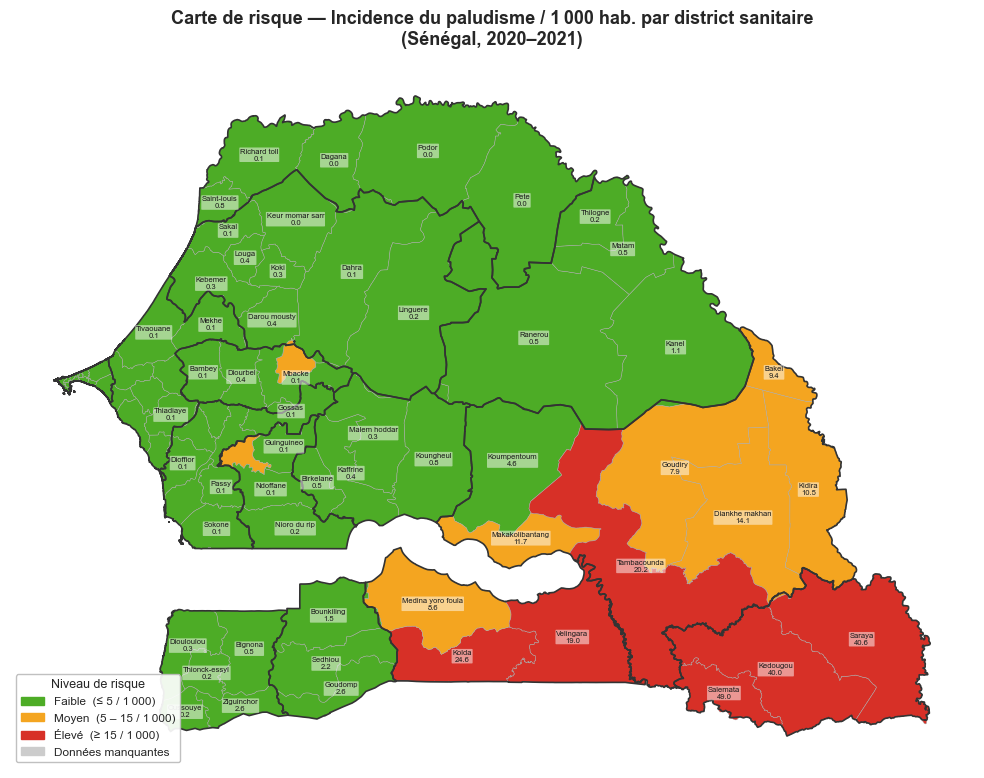

Carte exportée → carte_risque_district.png


In [17]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import unicodedata
import numpy as np
import os

# ── 1. Charger le shapefile des districts ────────────────────────────────────
dist_path = os.path.join("..", "donnees", "districts_sanitaire",
                         "Districts_sanitaires_Senegal_correct.shp")
gdf_dist = gpd.read_file(dist_path)
if gdf_dist.crs and gdf_dist.crs.to_epsg() != 4326:
    gdf_dist = gdf_dist.to_crs(epsg=4326)

# ── 2. Charger le shapefile des régions (pour les contours) ──────────────────
shp_reg_path = os.path.join("..", "donnees", "region", "region.shp")
gdf_reg2 = gpd.read_file(shp_reg_path)
if gdf_reg2.crs and gdf_reg2.crs.to_epsg() != 4326:
    gdf_reg2 = gdf_reg2.to_crs(epsg=4326)


def _norm(v):
    return unicodedata.normalize("NFD", str(v)).encode("ascii", "ignore").decode().strip().upper()


# ── 3. Incidence pondérée par population par district ───────────────────────
_df_d = df.dropna(subset=["district", "incident_1000"]).copy()
if "population" in df.columns:
    _df_d = _df_d.dropna(subset=["population"])
    _df_d["_wt"] = _df_d["incident_1000"] * _df_d["population"]
    _agg_d = _df_d.groupby("district")[["_wt", "population"]].sum()
    _agg_d["incidence_1000"] = _agg_d["_wt"] / _agg_d["population"]
else:
    _agg_d = _df_d.groupby("district")["incident_1000"].mean().rename("incidence_1000").to_frame()
_agg_d = _agg_d[["incidence_1000"]].reset_index()
_agg_d["_key"] = _agg_d["district"].map(_norm)
gdf_dist["_key"] = gdf_dist["district"].map(_norm)
gdf_dist_merged = gdf_dist.merge(_agg_d[["_key", "incidence_1000"]], on="_key", how="left")


# ── 4. Couleurs (mêmes seuils que le dashboard) ───────────────────────────────
def classify(v):
    if v is None or (isinstance(v, float) and np.isnan(v)):
        return "#cccccc"
    if v >= 15:
        return "#d73027"
    if v > 5:
        return "#f4a520"
    return "#4dac26"

gdf_dist_merged["_color"] = gdf_dist_merged["incidence_1000"].apply(classify)


# ── 5. Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_facecolor("white")
fig.patch.set_facecolor("white")

gdf_dist_merged.plot(ax=ax, color=gdf_dist_merged["_color"],
                     edgecolor="#aaaaaa", linewidth=0.35)

# Contours des régions par-dessus
gdf_reg2.plot(ax=ax, facecolor="none", edgecolor="#333333", linewidth=1.2)

# Étiquettes pour les grands districts (>= 30e percentile d'aire)
_areas = gdf_dist_merged.geometry.area
_threshold = np.percentile(_areas.dropna(), 30)
for _, row in gdf_dist_merged.iterrows():
    if row.geometry is None or row.geometry.area < _threshold:
        continue
    cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
    nom = str(row["district"]).capitalize()
    val = row["incidence_1000"]
    val_txt = f"{val:.1f}" if (isinstance(val, float) and not np.isnan(val)) else "N/A"
    ax.text(
        cx, cy, f"{nom}\n{val_txt}",
        fontsize=5.5, ha="center", va="center", color="#1a1a1a",
        bbox=dict(boxstyle="round,pad=0.1", fc="white", ec="none", alpha=0.5),
    )

# Légende
legend_patches = [
    mpatches.Patch(color="#4dac26", label="Faible  (≤ 5 / 1 000)"),
    mpatches.Patch(color="#f4a520", label="Moyen  (5 – 15 / 1 000)"),
    mpatches.Patch(color="#d73027", label="Élevé  (≥ 15 / 1 000)"),
    mpatches.Patch(color="#cccccc", label="Données manquantes"),
]
ax.legend(handles=legend_patches, title="Niveau de risque",
          title_fontsize=9, fontsize=8.5,
          loc="lower left", frameon=True, framealpha=0.92, edgecolor="#bbbbbb")

ax.set_title(
    "Carte de risque — Incidence du paludisme / 1 000 hab. par district sanitaire\n(Sénégal, 2020–2021)",
    fontsize=13, fontweight="bold", pad=14,
)
ax.axis("off")
plt.tight_layout()

plt.savefig("carte_risque_district.png", dpi=180, bbox_inches="tight", facecolor="white")
plt.show()
print("Carte exportée → carte_risque_district.png")